# From Ptolemy to Newton: benchmarking machine learning in the extrapolation regime

**A companion notebook to _"Is Deep Learning an Authentic Model of Natural Intelligence?"_ (Dizaji) and _"Direct Fit to Nature"_ (Hasson, Nastase & Goldstein, *Neuron* 2020).**

---

## The question

Hasson et al. (Figure 2) show that an over-parameterized ANN trained on a sine function generalizes
beautifully *inside* the training range and fails completely outside it: it interpolates, it does not
extrapolate. The essay pushes back with a historical observation: the progression
Ptolemy → Copernicus → Kepler → Newton runs from **highly-parameterized, specialized, interpolating**
models toward **under-parameterized, general, extrapolating** ones — and the latter are also the
*interpretable* ones.

This notebook turns that observation into a measurable claim:

> **H1 (the "Ptolemy→Newton" hypothesis).** Across simple *rule-learning* tasks, out-of-distribution
> (extrapolation) performance *decreases* with the number of effective parameters / description length,
> while in-distribution (interpolation) performance *increases*.

> **H2 (alignment, not frugality, is the causal variable).** What predicts extrapolation is whether the
> model's hypothesis space *contains* the generative rule and whether the search prefers it. A small model
> with the wrong hypothesis space extrapolates as badly as a big one.

> **H3 (priors can rescue over-parameterized models — the essay's Conjecture).** The same network
> extrapolates once the correct inductive bias is injected, *without* reducing its parameter count.

> **H4 (identifiability ceiling).** Some train/test splits make the rule underdetermined: many hypotheses
> fit the training region and disagree outside it. There, no learner can extrapolate without a prior.

---

## Headline results of the full run (`QUICK = False`, 3 seeds, 453 fits, 36 min on CPU)

**H1 is false in its strong form; H2 and H3 survive.** Specifically:

1. **The two leaderboards are not reversed — they are unrelated.** Spearman ρ between the
   interpolation and extrapolation rankings is **−0.086 (p = 0.73)**. Being small does not make a model
   extrapolate, and being large does not stop it.
2. **The clean capacity test points the *other* way.** Widening a single ReLU MLP from 4 to 1024 units
   *improves* extrapolation: ρ(log params, extrapolation) = **+0.82** on `poly` and **+0.91** on `add`,
   with the best scores at widths 512 and 128. Over-parameterization per se is not what blocks
   extrapolation.
3. **What does predict extrapolation is the hypothesis space.** Genetic-programming symbolic regression
   (5 parameters) scores **1.000 on every regression task**, and the dictionary searcher (3 parameters)
   scores 0.751 on average — while random forests, boosting, trees and k-NN sit at **−0.32 to −0.34**, and
   a degree-10 polynomial (11 parameters!) is the single worst model at **−1.00**. Frugality is neither
   necessary nor sufficient; containing the rule is.
4. **Priors beat both.** Symmetry-based data augmentation takes the *same* 64×64 network from −0.22 to
   **1.000** on `mult` and from −1.00 to **+0.44** on `sine`, with no change in parameter count — the
   essay's Conjecture, confirmed in the only form we can test cheaply.
5. **More data does not close the gap.** Across n = 10 → 1000, the slope of extrapolation score in
   log n is ≈ 0 for every model; the dictionary searcher is already at ceiling with **10 examples**,
   while forests and k-NN never arrive at any n.
6. **Representation converts extrapolation into interpolation.** On the Marcus ABA/ABB grammar, *no*
   model beats chance with one-hot tokens, most reach 0.95–1.00 with distributed embeddings, and *every*
   model is perfect under a relational recoding — same task, same labels, same capacity.
7. **For small open-weight LLMs, scale buys recall, not induction.** Across SmolLM2-135M → Qwen2.5-0.5B,
   exact-match on a *canonical* rule ($a+b$) in-range rises 0.08 → 0.11 → **0.81**, while the same models
   score **0.00 everywhere** on a freshly-parameterised twin ($8a+7b+55$) presented identically. The
   prior-knowledge gap widens with scale. The 3-parameter searcher scores 1.00 in all four cells.

The honest summary is that the essay's historical narrative is **directionally right but causally
mislabelled**: what improved from Ptolemy to Newton was the hypothesis space, not the parameter count.
Frugality followed from finding the right space; it did not cause it.

---

## What is deliberately *not* here

No physics-discovery networks (AI Feynman, PDE-nets, neural symbolic regression). The comparison is
between **basic, off-the-shelf learners** on the same rule-learning data with the same protocol.

## The protocol

Every task provides three disjoint sets from one known ground-truth rule:

| split | sampled from | measures |
|---|---|---|
| **train** | region $\mathcal{R}$ of input space | fitting |
| **interpolation test** | fresh samples from $\mathcal{R}$ | Hasson's "interpolation zone" |
| **extrapolation test** | region disjoint from $\mathcal{R}$ | the essay's "extreme generalization" |

Each model is scored with $R^2$/accuracy on both test sets, an **effective parameter count**, a
**description length in bits**, and a binary **rule-recovered** flag.

## Notebook map

| Part | Content |
|---|---|
| **0** | Setup, metrics, model implementations (MLP, symbolic MDL searcher) |
| **A** | Hasson et al. Fig. 2 replicated (space and time) **+ frugal models on the same axes** |
| **B** | The rule-learning task suite (9 train/test splits over 7 rules) |
| **C** | The model zoo (~19 learners spanning 5 orders of magnitude of parameters) |
| **D** | The benchmark run |
| **E** | Parameters vs. interpolation vs. extrapolation (**H1, H2**) |
| **F** | Capacity sweep: does *more* capacity ever buy extrapolation? |
| **G** | Priors ablation (**H3** — the essay's Conjecture) |
| **H** | Identifiability control (**H4**) |
| **I** | Open-weight LLMs across sizes: memorizable vs. freshly-generated rules |
| **K** | Sample efficiency: does *more data* close the extrapolation gap? |
| **L** | Extrapolation as a continuous axis: generalization difficulty $D$ and each model's $D^{*}$ |
| **J** | How to read the results, caveats, and extensions |

> **Runtime.** `QUICK = True` runs in 10–20 minutes on a free CPU Colab runtime. The results quoted above
> are from `QUICK = False` (3 seeds, gplearn enabled): about 36 minutes for Part D plus the later parts.
> Part I downloads open-weight models and is best run on a T4.

In [1]:
# ============================== 0. SETUP =====================================
import os, sys, math, time, json, itertools, warnings, subprocess
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

try:
    import torch
    import torch.nn as nn
except ImportError:                                   # not on Colab / fresh venv
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch"])
    import torch
    import torch.nn as nn

# ----------------------------- configuration ---------------------------------
QUICK    = False            # True -> fast pass (~5-15 min, CPU).  False -> full run.
SEEDS    = [0, 1, 2]       # repetitions: new data sample + new model init each time
N_TRAIN, N_INT, N_EXT = 600, 300, 300
NN_STEPS = 1500 if QUICK else 6000     # Adam steps for every MLP
USE_GPLEARN = not QUICK    # genetic-programming symbolic regression (slow but instructive)

RESULT_DIR = "results"; os.makedirs(RESULT_DIR, exist_ok=True)

if USE_GPLEARN:
    try:
        from gplearn.genetic import SymbolicRegressor
    except Exception:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gplearn"])
        try:
            from gplearn.genetic import SymbolicRegressor
        except Exception:
            USE_GPLEARN = False

torch.set_num_threads(max(1, (os.cpu_count() or 2)))
plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3,
                     "figure.facecolor": "white"})

print(f"numpy {np.__version__} | torch {torch.__version__} | "
      f"QUICK={QUICK} | seeds={SEEDS} | gplearn={USE_GPLEARN}")

numpy 2.1.3 | torch 2.11.0+cpu | QUICK=False | seeds=[0, 1, 2] | gplearn=True


## 0.1 Metrics, complexity accounting, and the two learners we implement ourselves

Three measurement choices carry the whole argument, so they are worth stating explicitly.

**Score.** Regression → $R^2$ computed *against the variance of the target set being evaluated*
(so an extrapolation $R^2$ of 0 means "no better than predicting the mean of the extrapolation zone",
and negative values mean worse than that). Classification → accuracy. We also record normalized RMSE,
which is scale-free and comparable across tasks.

**Effective parameter count.** This is the delicate one, because "number of parameters" means different
things for a k-NN regressor (which stores the training set) and for an MLP (which stores weights). We use
a uniform *storage* convention: **how many real numbers must be written down to reproduce the model's
predictions**. Hence

| model | counted as |
|---|---|
| linear / polynomial / sparse regression | non-zero coefficients + intercept |
| $k$-NN | $n_\text{train} \times (d+1)$ — the model *is* the data (Hasson's "direct fit" limit) |
| decision tree / forest / boosting | 2 × total node count (split threshold + value) |
| kernel ridge / SVM / GP | number of dual coefficients (+ support vectors / kernel hyper-parameters) |
| MLP / LSTM | `sum(p.numel())` |
| symbolic (MDL search, gplearn) | coefficients + expression-tree size |

**Description length in bits.** `n_params × 32` for numeric models; for the symbolic searcher we add
$k\log_2 p$ bits to encode *which* $p$ dictionary primitives were selected. This makes "frugality" in
the essay's sense (Kepler's three laws vs. Ptolemy's epicycles) an explicit axis of the plots.
It is a proxy, not a formal MDL — but it is monotone in the quantity the essay cares about.

**Two learners are implemented from scratch** because they are exactly the ends of the spectrum we
want to compare:

1. `TorchMLP` — a plain over-parameterizable feed-forward net (width, depth, activation, weight decay
   are all exposed, because in Part G they become the *prior*).
2. `MDLFormula` — a "Kepler machine": it builds a small dictionary of primitive functions
   ($x_i$, $x_i^2$, $x_i^3$, $x_i x_j$, $\sin\omega x_i$, $\cos\omega x_i$, $|x_i|$), searches over
   subsets of size ≤ 3, fits coefficients by least squares, and selects by BIC. It returns a
   **human-readable formula**. Note the honest caveat, which is itself one of the findings: this model
   can only recover a rule that its primitive set can express. Its priors are its power *and* its limit —
   precisely the "Core Knowledge priors" argument in the essay.

In [2]:
# =================== 0.2 metrics & complexity accounting =====================
BITS_PER_PARAM = 32.0


def r2(y, yh):
    y = np.asarray(y, float).ravel(); yh = np.asarray(yh, float).ravel()
    return float(1.0 - np.mean((y - yh) ** 2) / (np.var(y) + 1e-12))


def nrmse(y, yh):
    y = np.asarray(y, float).ravel(); yh = np.asarray(yh, float).ravel()
    return float(np.sqrt(np.mean((y - yh) ** 2)) / (np.std(y) + 1e-12))


def accuracy(y, yh):
    return float(np.mean(np.asarray(y).ravel() == np.asarray(yh).ravel()))


def score(kind, y, yh):
    """Primary score: R^2 for regression, accuracy for classification."""
    return r2(y, yh) if kind == "regression" else accuracy(y, yh)


def rule_recovered(kind, y, yh):
    """Did the model effectively recover the generative rule in this zone?"""
    return bool(nrmse(y, yh) < 0.10) if kind == "regression" else bool(accuracy(y, yh) > 0.95)


def count_params(est, n_train, d):
    """Effective number of real numbers needed to reproduce the estimator."""
    name = type(est).__name__
    # --- memory-based models: the model *is* the training set -----------------
    if "KNeighbors" in name:
        return int(n_train * (d + 1))
    # --- trees and ensembles --------------------------------------------------
    if hasattr(est, "tree_"):
        return int(2 * est.tree_.node_count)
    if hasattr(est, "estimators_"):
        tot = 0
        for e in np.ravel(np.asarray(est.estimators_, dtype=object)):
            if hasattr(e, "tree_"):
                tot += 2 * e.tree_.node_count
        return int(max(tot, 1))
    # --- kernel machines ------------------------------------------------------
    if hasattr(est, "support_vectors_"):
        return int(np.size(est.dual_coef_) + np.size(est.support_vectors_))
    if hasattr(est, "dual_coef_"):
        return int(np.size(est.dual_coef_))
    if hasattr(est, "X_train_"):                      # GaussianProcess*
        return int(np.size(est.X_train_) + np.size(getattr(est, "alpha_", [])) +
                   len(est.kernel_.theta))
    # --- (generalized) linear models -----------------------------------------
    if hasattr(est, "coef_"):
        c = np.asarray(est.coef_)
        nz = int(np.sum(np.abs(c) > 1e-10)) if "Lasso" in name or "Elastic" in name else int(c.size)
        return int(nz + np.size(getattr(est, "intercept_", 0.0)))
    return int(n_train)                               # conservative fallback


def desc_bits(n_params, extra_bits=0.0):
    return float(n_params * BITS_PER_PARAM + extra_bits)

In [3]:
# ============ 0.3 a plain (over-parameterizable) feed-forward network ========
class Sin(nn.Module):
    def forward(self, x):
        return torch.sin(x)


ACTS = {"relu": nn.ReLU, "tanh": nn.Tanh, "sin": Sin, "gelu": nn.GELU}


class TorchMLP:
    """Plain MLP. Width / depth / activation / weight-decay are exposed because in
    Part G they are treated as *inductive biases*, not as tuning knobs."""
    family = "neural"

    def __init__(self, hidden=(64, 64), act="relu", steps=None, lr=3e-3, wd=0.0,
                 seed=0, name=None, augment=None):
        self.hidden = tuple(hidden); self.act = act
        self.steps = NN_STEPS if steps is None else steps
        self.lr = lr; self.wd = wd; self.seed = seed
        self.augment = augment            # callable (X, y, rng) -> (X, y); a prior
        self.name = name or f"MLP {'x'.join(map(str, self.hidden))} [{act}]"

    # ---------------------------------------------------------------- build --
    def _build(self, d_in):
        layers, prev = [], d_in
        for h in self.hidden:
            layers += [nn.Linear(prev, h), ACTS[self.act]()]
            prev = h
        layers += [nn.Linear(prev, 1)]
        return nn.Sequential(*layers)

    # ------------------------------------------------------------------ fit --
    def fit(self, X, y, kind):
        self.kind = kind
        torch.manual_seed(self.seed)
        rng = np.random.default_rng(self.seed)
        X = np.asarray(X, float); y = np.asarray(y, float).ravel()
        if self.augment is not None:
            X, y = self.augment(X, y, rng)

        # standardisation uses TRAIN statistics only (a fixed affine map applied
        # identically at test time -- it cannot by itself create or destroy the
        # ability to extrapolate, it only helps optimisation)
        self.mu, self.sd = X.mean(0), X.std(0) + 1e-8
        Xs = (X - self.mu) / self.sd
        if kind == "regression":
            self.ymu, self.ysd = float(y.mean()), float(y.std() + 1e-8)
            t = (y - self.ymu) / self.ysd
            lossf = nn.MSELoss()
        else:
            self.ymu, self.ysd = 0.0, 1.0
            t = y.astype(float)
            lossf = nn.BCEWithLogitsLoss()

        Xt = torch.tensor(Xs, dtype=torch.float32)
        yt = torch.tensor(t, dtype=torch.float32).view(-1, 1)
        self.net = self._build(Xt.shape[1])
        opt = torch.optim.Adam(self.net.parameters(), lr=self.lr, weight_decay=self.wd)
        n = Xt.shape[0]; bs = min(128, n)
        for _ in range(self.steps):
            idx = torch.randint(0, n, (bs,))
            opt.zero_grad()
            loss = lossf(self.net(Xt[idx]), yt[idx])
            loss.backward()
            opt.step()
        self.final_loss = float(loss.item())
        return self

    # -------------------------------------------------------------- predict --
    def predict(self, X):
        Xs = (np.asarray(X, float) - self.mu) / self.sd
        with torch.no_grad():
            o = self.net(torch.tensor(Xs, dtype=torch.float32)).numpy().ravel()
        if self.kind == "regression":
            return o * self.ysd + self.ymu
        return (o > 0).astype(int)

    @property
    def n_params(self):
        return int(sum(p.numel() for p in self.net.parameters()))

    @property
    def bits(self):
        return desc_bits(self.n_params)

    formula = None

In [4]:
# ====== 0.4 a "Kepler machine": dictionary search + BIC/MDL model selection ===
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


class MDLFormula:
    """Searches a small dictionary of primitive functions for the shortest
    expression (<= max_terms) that explains the data, scored by BIC plus the
    code length of the subset choice. Returns a readable formula.

    Its hypothesis space *is* its prior: it can only recover rules expressible in
    its primitive set -- the machine-learning analogue of 'Core Knowledge priors'."""
    family = "symbolic"

    def __init__(self, max_terms=3, freqs=(0.5, 1.0, 2.0, 3.0), exhaustive_limit=45,
                 max_features=500, name="MDL formula search", seed=0):
        self.max_terms = max_terms; self.freqs = freqs
        self.exhaustive_limit = exhaustive_limit
        self.max_features = max_features        # keeps the search tractable in high d
        self.name = name; self.seed = seed

    # -------------------------------------------------------- dictionary -----
    def _dictionary(self, X):
        X = np.asarray(X, float); d = X.shape[1]
        names, cols = [], []

        def add_group(group):
            if len(names) + len(group) > self.max_features:
                return                          # whole group skipped: budget exceeded
            for nm, v in group:
                names.append(nm)
                cols.append(np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0))

        add_group([(f"x{i}", X[:, i]) for i in range(d)])
        add_group([(f"x{i}^2", X[:, i] ** 2) for i in range(d)])
        add_group([(f"x{i}^3", X[:, i] ** 3) for i in range(d)])
        add_group([(f"x{i}*x{j}", X[:, i] * X[:, j])
                   for i in range(d) for j in range(i + 1, d)])
        add_group([(f"{fn}({w:g}x{i})", f(w * X[:, i]))
                   for w in self.freqs for i in range(d)
                   for fn, f in (("sin", np.sin), ("cos", np.cos))])
        add_group([(f"|x{i}|", np.abs(X[:, i])) for i in range(d)])
        return names, np.column_stack(cols)

    # ------------------------------------------------------------- helpers ---
    @staticmethod
    def _ols(F, y, S):
        A = np.column_stack([np.ones(len(y))] + [F[:, j] for j in S])
        coef, *_ = np.linalg.lstsq(A, y, rcond=None)
        res = y - A @ coef
        return coef, float(res @ res)

    def _greedy(self, F, y, fit_fn):
        """Forward selection; returns the nested candidate subsets."""
        p = F.shape[1]; chosen, cands = [], []
        for _ in range(self.max_terms):
            best_j, best_c = None, np.inf
            for j in range(p):
                if j in chosen:
                    continue
                c = fit_fn(chosen + [j])
                if c < best_c:
                    best_c, best_j = c, j
            if best_j is None:
                break
            chosen = chosen + [best_j]
            cands.append(list(chosen))
        return cands

    # ----------------------------------------------------------------- fit ---
    def fit(self, X, y, kind):
        self.kind = kind
        y = np.asarray(y, float).ravel()
        names, F = self._dictionary(X)
        self.p = F.shape[1]; n = len(y)

        if kind == "regression":
            cost = lambda S: self._ols(F, y, S)[1]
            if self.p <= self.exhaustive_limit:
                cands = [list(S) for k in range(1, self.max_terms + 1)
                         for S in itertools.combinations(range(self.p), k)]
            else:
                cands = self._greedy(F, y, cost)
            best = (np.inf, None, None)
            for S in cands:
                coef, rss = self._ols(F, y, S)
                k = len(S) + 1
                bic = (n * np.log(max(rss, 1e-12) / n) + k * np.log(n)
                       + len(S) * np.log(max(self.p, 2)))          # subset code length
                if bic < best[0]:
                    best = (bic, S, coef)
            self.bic, self.S, self.coef = best
            terms = " + ".join(f"{c:.4g}*{names[j]}" for c, j in zip(self.coef[1:], self.S))
            self.formula = f"y = {terms} + {self.coef[0]:.4g}"
        else:
            self.scaler = StandardScaler().fit(F)
            Fs = self.scaler.transform(F)

            def clf_cost(S):
                if not S:
                    return np.inf
                m = LogisticRegression(max_iter=1000).fit(Fs[:, S], y)
                pr = np.clip(m.predict_proba(Fs[:, S])[:, 1], 1e-9, 1 - 1e-9)
                ll = float(np.sum(y * np.log(pr) + (1 - y) * np.log(1 - pr)))
                return -2 * ll + (len(S) + 1) * np.log(n) + len(S) * np.log(max(self.p, 2))

            if self.p <= self.exhaustive_limit:
                cands = [list(S) for k in range(1, self.max_terms + 1)
                         for S in itertools.combinations(range(self.p), k)]
            else:
                cands = self._greedy(Fs, y, clf_cost)
            best = (np.inf, None)
            for S in cands:
                c = clf_cost(S)
                if c < best[0]:
                    best = (c, S)
            self.bic, self.S = best
            self.model = LogisticRegression(max_iter=1000).fit(Fs[:, self.S], y)
            self.formula = ("P(y=1) = sigmoid(" +
                            " + ".join(f"{c:.3g}*{names[j]}"
                                       for c, j in zip(self.model.coef_.ravel(), self.S)) +
                            f" + {float(self.model.intercept_[0]):.3g})")
        self.names = names
        return self

    # ------------------------------------------------------------- predict ---
    def predict(self, X):
        _, F = self._dictionary(X)
        if self.kind == "regression":
            A = np.column_stack([np.ones(len(F))] + [F[:, j] for j in self.S])
            return A @ self.coef
        Fs = self.scaler.transform(F)
        return self.model.predict(Fs[:, self.S]).astype(int)

    @property
    def n_params(self):
        return int(len(self.S) + 1)

    @property
    def bits(self):
        return desc_bits(self.n_params, extra_bits=len(self.S) * np.log2(max(self.p, 2)))

---
# Part A — Replicating Hasson et al. (2020), Figure 2, and adding the frugal models

Figure 2 of *Direct Fit to Nature* makes its point with one model class: an over-parameterized ANN
(~180,600 weights) trained on $\sin(x)$ for $-5<x<5$, then asked to predict on $-15<x<15$. It interpolates
perfectly and extrapolates not at all. The figure is a fair demonstration — about *one family of learners*.

The essay's counter-claim implies a checkable prediction: a learner whose hypothesis space is small enough
to contain the generative rule, and whose selection criterion prefers short descriptions, will recover
$\sin(x)$ from the same data and extrapolate over the whole line. Part A puts both kinds on the same axes.

### What the full run gives

**A.1 (over space).** The replication is exact — and the contrast is total:

| model | parameters | $R^2$ interpolation | $R^2$ extrapolation |
|---|---:|---:|---:|
| MLP 300×300×300 (ReLU) | 181,501 | 0.998 | **−1.46** |
| k-NN (k=5) | 4,000 | 0.999 | −2.16 |
| Random forest (100 trees) | 504,380 | 0.998 | −2.15 |
| Polynomial ridge (deg. 9) | 11 | 1.000 | **−1.3 × 10⁸** |
| MDL formula search | **2** | 1.000 | **+1.000** |

Two things to notice. First, the 2-parameter searcher returns
`y = 0.9985*sin(1*x0) − 0.000129` — it did not merely score well, it *wrote down the rule*, which is the
property the essay is really arguing about. Second, the degree-9 polynomial is the counter-example to any
simple reading of H1: it is the **smallest** model in the table and by far the **worst** extrapolator.
Frugality without the right hypothesis space buys nothing. That is Ptolemy's epicycles in miniature — a
compact, flexible, beautifully-fitting, entirely local model.

**A.2 (over time).** The LSTM (23,652 parameters, final train MSE 0.0015) reproduces the paper's result
exactly: $R^2$ = 0.995 and 0.994 at the two held-out frequencies *inside* the training band (3 and 4 Hz),
and **−1.57, −2.37, −3.46, −2.81** at 1, 2, 5 and 6 Hz outside it. A 4-parameter oscillator fitted to the
*same 1-second input window* scores **1.000 at all six frequencies**, including the ones the LSTM has
never seen. The information needed to extrapolate was present in the input the whole time; what the LSTM
lacked was a hypothesis space in which "a sinusoid of unknown frequency" is a single object.

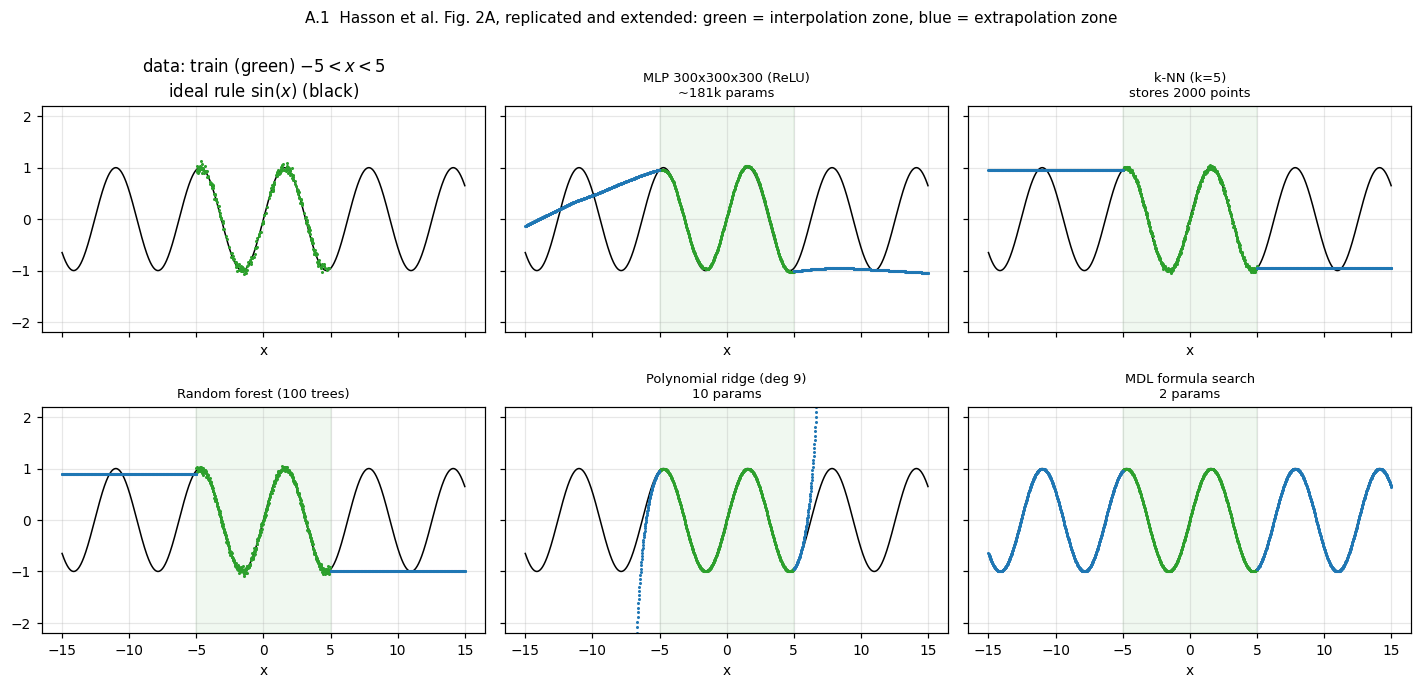

                              model  n_params  R2_interp     R2_extrap  seconds                         formula
MLP 300x300x300 (ReLU) ~181k params    181501      0.998 -1.459000e+00    144.2                            None
      k-NN (k=5) stores 2000 points      4000      0.999 -2.155000e+00      0.1                            None
          Random forest (100 trees)    504380      0.998 -2.146000e+00      0.4                            None
 Polynomial ridge (deg 9) 10 params        11      1.000 -1.338539e+08      0.0                            None
        MDL formula search 2 params         2      1.000  1.000000e+00      0.1 y = 0.9985*sin(1x0) + -0.000129


In [5]:
# ============ A.1  interpolation / extrapolation over SPACE ==================
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

rng = np.random.default_rng(0)
x_tr = rng.uniform(-5, 5, 2000)                      # the "interpolation zone"
y_tr = np.sin(x_tr) + rng.normal(0, 0.05, x_tr.size)
x_all = np.linspace(-15, 15, 1500)                   # spans both zones
y_all = np.sin(x_all)
Xtr, Xall = x_tr[:, None], x_all[:, None]
in_zone = np.abs(x_all) <= 5

fitters = {
    "MLP 300x300x300 (ReLU)\n~181k params":
        lambda: TorchMLP(hidden=(300, 300, 300), act="relu", steps=NN_STEPS, seed=0),
    "k-NN (k=5)\nstores 2000 points":
        lambda: make_pipeline(KNeighborsRegressor(5)),
    "Random forest (100 trees)":
        lambda: RandomForestRegressor(100, random_state=0, n_jobs=-1),
    "Polynomial ridge (deg 9)\n10 params":
        lambda: make_pipeline(PolynomialFeatures(9), Ridge(1e-6)),
    "MDL formula search\n2 params":
        lambda: MDLFormula(),
}

fig, axes = plt.subplots(2, 3, figsize=(13, 6.2), sharex=True, sharey=True)
axes = axes.ravel()
axes[0].plot(x_all, y_all, "k-", lw=1)
axes[0].plot(x_tr[::8], y_tr[::8], ".", color="tab:green", ms=2)
axes[0].set_title("data: train (green) $-5<x<5$\nideal rule $\\sin(x)$ (black)")
axes[0].set_ylim(-2.2, 2.2)

rowsA = []
for ax, (nm, mk) in zip(axes[1:], fitters.items()):
    m = mk()
    t0 = time.time()
    if isinstance(m, (TorchMLP, MDLFormula)):
        m.fit(Xtr, y_tr, "regression"); npar = m.n_params
    else:
        m.fit(Xtr, y_tr); npar = count_params(m[-1] if hasattr(m, "steps") else m, len(Xtr), 1)
    pred = m.predict(Xall)
    ax.plot(x_all, y_all, "k-", lw=1)
    ax.plot(x_all[in_zone], pred[in_zone], ".", color="tab:green", ms=2)
    ax.plot(x_all[~in_zone], pred[~in_zone], ".", color="tab:blue", ms=2)
    ax.axvspan(-5, 5, color="tab:green", alpha=.07)
    ax.set_title(nm, fontsize=8.5)
    rowsA.append(dict(model=nm.replace("\n", " "), n_params=npar,
                      R2_interp=round(r2(y_all[in_zone], pred[in_zone]), 3),
                      R2_extrap=round(r2(y_all[~in_zone], pred[~in_zone]), 3),
                      seconds=round(time.time() - t0, 1),
                      formula=getattr(m, "formula", None)))
for ax in axes:
    ax.set_xlabel("x")
fig.suptitle("A.1  Hasson et al. Fig. 2A, replicated and extended: green = interpolation zone, "
             "blue = extrapolation zone", y=1.0, fontsize=10)
plt.tight_layout(); plt.show()

dfA = pd.DataFrame(rowsA)
print(dfA.to_string(index=False))

LSTM: 23,652 parameters, final train MSE 0.0015


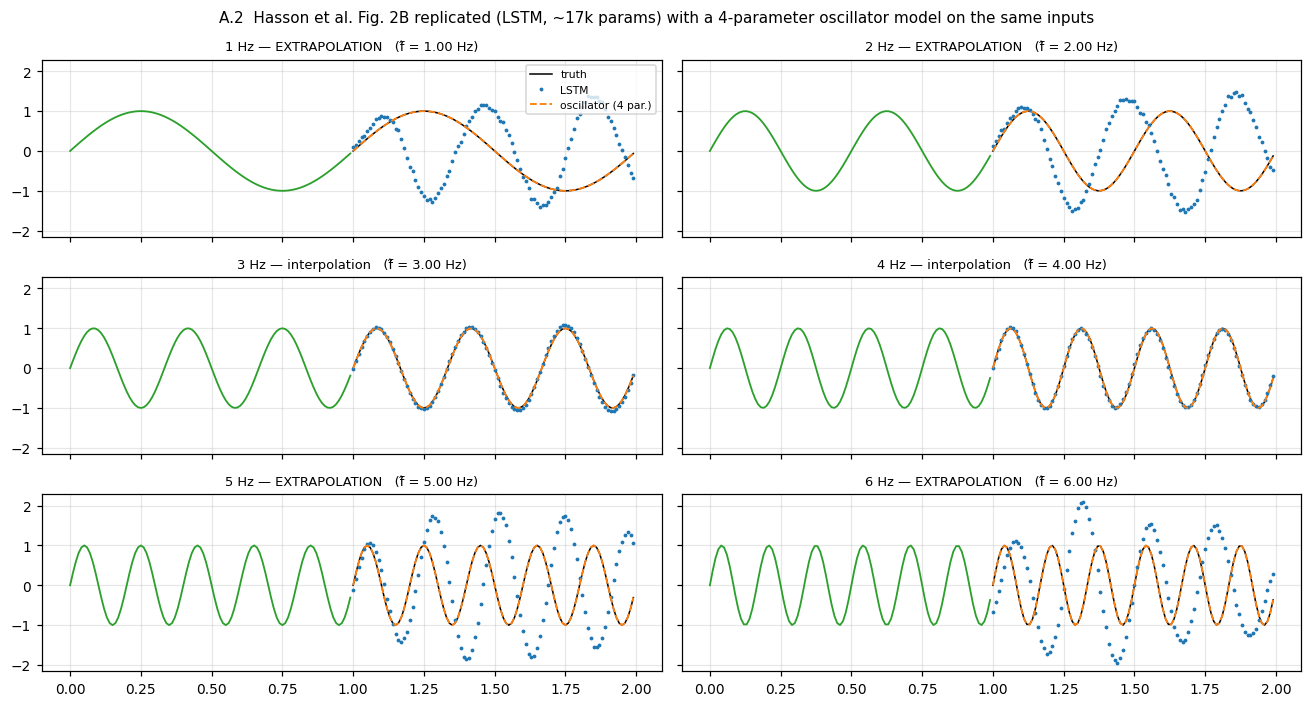

 freq_Hz          zone  R2_LSTM  R2_oscillator
     1.0 EXTRAPOLATION   -1.568            1.0
     2.0 EXTRAPOLATION   -2.370            1.0
     3.0 interpolation    0.995            1.0
     4.0 interpolation    0.994            1.0
     5.0 EXTRAPOLATION   -3.464            1.0
     6.0 EXTRAPOLATION   -2.805            1.0


In [6]:
# ============ A.2  interpolation / extrapolation over TIME ===================
FS, WIN = 100, 100                      # 100 Hz sampling, 1 s input window
t_in = np.arange(WIN) / FS
t_out = np.arange(WIN, 2 * WIN) / FS


def make_seq(freqs, rng, phase=None):
    ph = rng.uniform(0, 2 * np.pi, len(freqs)) if phase is None else np.full(len(freqs), phase)
    X = np.sin(2 * np.pi * freqs[:, None] * t_in[None, :] + ph[:, None])
    Y = np.sin(2 * np.pi * freqs[:, None] * t_out[None, :] + ph[:, None])
    return X, Y


rng = np.random.default_rng(1)
n_seq = 3000
f_tr = rng.uniform(2.5, 4.5, n_seq)                       # training zone
f_tr = f_tr[(np.abs(f_tr - 3) > .1) & (np.abs(f_tr - 4) > .1)]   # hold out 3 and 4 Hz
Xs, Ys = make_seq(f_tr, rng)


class LSTMSeq(nn.Module):
    def __init__(self, hidden=64, out=WIN):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, batch_first=True)
        self.head = nn.Linear(hidden, out)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.head(h[-1])


torch.manual_seed(0)
lstm = LSTMSeq()
opt = torch.optim.Adam(lstm.parameters(), lr=3e-3)
Xt = torch.tensor(Xs, dtype=torch.float32).unsqueeze(-1)
Yt = torch.tensor(Ys, dtype=torch.float32)
steps = 600 if QUICK else 3000
for s in range(steps):
    idx = torch.randint(0, Xt.shape[0], (64,))
    opt.zero_grad()
    loss = ((lstm(Xt[idx]) - Yt[idx]) ** 2).mean()
    loss.backward(); opt.step()
print(f"LSTM: {sum(p.numel() for p in lstm.parameters()):,} parameters, "
      f"final train MSE {loss.item():.4f}")


# --- the frugal alternative: a 4-parameter oscillator fitted to the same window
FGRID = np.arange(0.2, 10.0, 0.01)


def fit_oscillator(y, t=t_in, fgrid=FGRID):
    best = (np.inf, None, None)
    for f in fgrid:
        A = np.column_stack([np.sin(2 * np.pi * f * t), np.cos(2 * np.pi * f * t), np.ones_like(t)])
        c, *_ = np.linalg.lstsq(A, y, rcond=None)
        rss = float(np.sum((y - A @ c) ** 2))
        if rss < best[0]:
            best = (rss, f, c)
    _, f, c = best
    return lambda tt: np.column_stack([np.sin(2 * np.pi * f * tt),
                                       np.cos(2 * np.pi * f * tt), np.ones_like(tt)]) @ c, f


test_f = np.array([1., 2., 3., 4., 5., 6.])
Xte, Yte = make_seq(test_f, np.random.default_rng(2), phase=0.0)
with torch.no_grad():
    pred_lstm = lstm(torch.tensor(Xte, dtype=torch.float32).unsqueeze(-1)).numpy()

fig, axes = plt.subplots(3, 2, figsize=(12, 6.5), sharex=True, sharey=True)
rowsB = []
for i, (ax, f) in enumerate(zip(axes.ravel(), test_f)):
    osc, f_hat = fit_oscillator(Xte[i])
    pred_osc = osc(t_out)
    zone = "interpolation" if 2.5 <= f <= 4.5 else "EXTRAPOLATION"
    ax.plot(t_in, Xte[i], color="tab:green", lw=1.2)
    ax.plot(t_out, Yte[i], "k-", lw=1, label="truth")
    ax.plot(t_out, pred_lstm[i], ".", color="tab:blue", ms=3, label="LSTM")
    ax.plot(t_out, pred_osc, "--", color="tab:orange", lw=1.2, label="oscillator (4 par.)")
    ax.set_title(f"{f:.0f} Hz — {zone}   (f̂ = {f_hat:.2f} Hz)", fontsize=8.5)
    rowsB.append(dict(freq_Hz=f, zone=zone,
                      R2_LSTM=round(r2(Yte[i], pred_lstm[i]), 3),
                      R2_oscillator=round(r2(Yte[i], pred_osc), 3)))
axes[0, 0].legend(fontsize=7, loc="upper right")
fig.suptitle("A.2  Hasson et al. Fig. 2B replicated (LSTM, ~17k params) with a 4-parameter "
             "oscillator model on the same inputs", fontsize=10)
plt.tight_layout(); plt.show()
print(pd.DataFrame(rowsB).to_string(index=False))

---
# Part B — A rule-learning benchmark with an explicit extrapolation zone

ARC is the right *kind* of test (few examples, novel task, explicit priors) but, as the essay notes, it
is out of reach for ordinary learners — a benchmark on which every model scores zero measures nothing.
We therefore use seven rules (nine train/test splits) that keep ARC's *logic* (a short, exact, compositional rule; a test region
the training region does not cover) while remaining solvable by standard regressors and classifiers.

| task | inputs | rule | training region | extrapolation region | why it is here |
|---|---|---|---|---|---|
| `poly` | $x$ | $x^2-3x+2$ | $|x|<5$ | $5<|x|<15$ | Hasson's own Fig. 1B "ideal-fit parabola" |
| `sine` | $x$ | $\sin x$ | $|x|<5$ | $5<|x|<15$ | Hasson's Fig. 2A, inside the benchmark |
| `add` | $a,b$ | $a+b$ | $[0,50]^2$ | $[50,200]^2$ | the simplest compositional rule there is |
| `mult` | $a,b$ | $a\cdot b$ | $[1,10]^2$ | $[10,30]^2$ | multiplicative structure (notoriously hard for MLPs) |
| `ap_next` | 5 terms of an arithmetic progression | next term $=2x_5-x_4$ | small start & step | large start & step | sequence-rule induction; linearly expressible |
| `parity` | 14 bits | parity of the bits | Hamming weight ≤ 5 | Hamming weight ≥ 9 | a discrete, non-local Boolean rule |
| `grammar_1hot` | 3 tokens, one-hot (120 d) | ABA vs. ABB (Marcus et al., 1999) | vocabulary $V_1$ (20 tokens) | **unseen vocabulary $V_2$** | variable binding: the classic *infant* rule-learning experiment |
| `grammar_emb` | same sequences, tokens as 8-d random vectors | same rule | same | same | novel tokens are novel *values*, not novel *units* |
| `grammar_rel` | same sequences, re-coded as 3 pairwise similarities | same rule | same | same | the *same task under a relational prior* — a preview of Part G |

Two design points worth flagging:

* **`grammar` is the neuroscience anchor.** Marcus, Vijayan, Bandi Rao & Vishton (*Science*, 1999) showed
  that 7-month-olds habituated to `ABA` strings generalize the pattern to strings built from *syllables
  they have never heard*. That is extrapolation in the strict sense: the test items lie outside the
  training distribution's support, and success requires an abstract, variable-binding rule rather than
  token statistics. It is the cleanest developmental evidence for the essay's position, and it is cheap
  to simulate.
* **The three `grammar` variants are a controlled manipulation of priors, not of capacity.** Identical
  sequences, identical labels, identical models — only the *input representation* changes, and with it
  the amount of built-in knowledge about what counts as a feature:
  under **one-hot** coding a novel token activates units that were identically zero during training, so
  nothing whatsoever transfers; under **distributed embeddings** a novel token is a novel *value* of
  features the model has already seen, so a coarse "same/different" detector can transfer partially;
  under the **relational** coding the identity relation is handed to the model and the task collapses to
  a threshold. Watch how far each learner climbs this ladder — and note that the ladder is a property of
  the representation, not of the learner.

In [7]:
# ====================== B.1  the task suite ==================================
class Task:
    def __init__(self, name, kind, rule, Xtr, ytr, Xin, yin, Xex, yex, note=""):
        self.name, self.kind, self.rule, self.note = name, kind, rule, note
        self.Xtr, self.ytr = np.asarray(Xtr, float), np.asarray(ytr)
        self.Xin, self.yin = np.asarray(Xin, float), np.asarray(yin)
        self.Xex, self.yex = np.asarray(Xex, float), np.asarray(yex)
        self.d = self.Xtr.shape[1]

    def __repr__(self):
        return (f"<Task {self.name} ({self.kind}, d={self.d}) rule: {self.rule} | "
                f"n={len(self.Xtr)}/{len(self.Xin)}/{len(self.Xex)}>")


def _poly(seed):
    g = np.random.default_rng(100 + seed); f = lambda x: x ** 2 - 3 * x + 2
    xt = g.uniform(-5, 5, N_TRAIN); xi = g.uniform(-5, 5, N_INT)
    xe = g.choice([-1, 1], N_EXT) * g.uniform(5, 15, N_EXT)
    return Task("poly", "regression", "y = x^2 - 3x + 2",
                xt[:, None], f(xt) + g.normal(0, .5, N_TRAIN),
                xi[:, None], f(xi), xe[:, None], f(xe))


def _sine(seed):
    g = np.random.default_rng(200 + seed); f = np.sin
    xt = g.uniform(-5, 5, N_TRAIN); xi = g.uniform(-5, 5, N_INT)
    xe = g.choice([-1, 1], N_EXT) * g.uniform(5, 15, N_EXT)
    return Task("sine", "regression", "y = sin(x)",
                xt[:, None], f(xt) + g.normal(0, .05, N_TRAIN),
                xi[:, None], f(xi), xe[:, None], f(xe))


def _add(seed):
    g = np.random.default_rng(300 + seed); f = lambda X: X[:, 0] + X[:, 1]
    Xt = g.uniform(0, 50, (N_TRAIN, 2)); Xi = g.uniform(0, 50, (N_INT, 2))
    Xe = g.uniform(50, 200, (N_EXT, 2))
    return Task("add", "regression", "y = a + b", Xt, f(Xt), Xi, f(Xi), Xe, f(Xe))


def _mult(seed):
    g = np.random.default_rng(400 + seed); f = lambda X: X[:, 0] * X[:, 1]
    Xt = g.uniform(1, 10, (N_TRAIN, 2)); Xi = g.uniform(1, 10, (N_INT, 2))
    Xe = g.uniform(10, 30, (N_EXT, 2))
    return Task("mult", "regression", "y = a * b", Xt, f(Xt), Xi, f(Xi), Xe, f(Xe))


def _ap_next(seed):
    g = np.random.default_rng(500 + seed)

    def gen(n, a_lo, a_hi, d_lo, d_hi):
        a = g.uniform(a_lo, a_hi, n); d = g.uniform(d_lo, d_hi, n)
        X = a[:, None] + d[:, None] * np.arange(5)[None, :]
        return X, a + 5 * d

    Xt, yt = gen(N_TRAIN, 0, 20, 1, 5)
    Xi, yi = gen(N_INT, 0, 20, 1, 5)
    Xe, ye = gen(N_EXT, 100, 200, 6, 15)
    return Task("ap_next", "regression", "next term of an arithmetic progression (= 2*x5 - x4)",
                Xt, yt, Xi, yi, Xe, ye,
                note="extrapolation in both the starting value and the step size")


def _parity(seed, nbits=14, w_tr=5, w_ex=9):
    g = np.random.default_rng(600 + seed)

    def sample(n, lo, hi, seen):
        out = []
        while len(out) < n:
            w = g.integers(lo, hi + 1)
            v = np.zeros(nbits, int); v[g.choice(nbits, w, replace=False)] = 1
            key = tuple(v)
            if key not in seen:
                seen.add(key); out.append(v)
        return np.array(out)

    seen = set()
    Xt = sample(N_TRAIN, 0, w_tr, seen)
    Xi = sample(N_INT, 0, w_tr, seen)
    Xe = sample(N_EXT, w_ex, nbits, set())
    par = lambda X: X.sum(1) % 2
    return Task("parity", "classification", f"y = parity of {nbits} bits",
                Xt, par(Xt), Xi, par(Xi), Xe, par(Xe),
                note=f"train/test-int: Hamming weight <= {w_tr}; extrapolation: weight >= {w_ex}")


def _grammar(seed, coding="onehot", n_vocab=40, dim=8):
    """Marcus et al. (1999) ABA / ABB artificial grammar, tested on an UNSEEN vocabulary.

    coding = "onehot"     : a novel token activates input units never active in training
             "embedding"  : tokens are random 8-d vectors (novel tokens are novel *values*)
             "relational" : the sequence is recoded as 3 pairwise similarities (a prior)
    """
    g = np.random.default_rng(700 + seed)
    emb = g.normal(0, 1, (n_vocab, dim))
    emb /= np.linalg.norm(emb, axis=1, keepdims=True)
    train_vocab, test_vocab = np.arange(0, 20), np.arange(20, 40)

    def encode(toks):
        if coding == "onehot":
            E = np.eye(n_vocab)
        elif coding == "embedding":
            E = emb
        else:
            return np.stack([(emb[toks[:, 0]] * emb[toks[:, 1]]).sum(1),
                             (emb[toks[:, 0]] * emb[toks[:, 2]]).sum(1),
                             (emb[toks[:, 1]] * emb[toks[:, 2]]).sum(1)], 1)
        return np.concatenate([E[toks[:, 0]], E[toks[:, 1]], E[toks[:, 2]]], 1)

    def gen(n, vocab):
        A = g.choice(vocab, n)
        B = np.array([g.choice(vocab[vocab != a]) for a in A])
        lab = g.integers(0, 2, n)                    # 0 = ABA, 1 = ABB
        toks = np.stack([A, B, np.where(lab == 0, A, B)], 1)
        return encode(toks), lab

    Xt, yt = gen(N_TRAIN, train_vocab)
    Xi, yi = gen(N_INT, train_vocab)
    Xe, ye = gen(N_EXT, test_vocab)                  # tokens NEVER seen during training
    nm = {"onehot": "grammar_1hot", "embedding": "grammar_emb",
          "relational": "grammar_rel"}[coding]
    note = {"onehot": "novel tokens = input units that were always 0 in training",
            "embedding": "novel tokens = novel values of 8-d distributed features",
            "relational": "same/different recoding: 3 pairwise similarities"}[coding]
    return Task(nm, "classification", "ABA (0) vs ABB (1)", Xt, yt, Xi, yi, Xe, ye, note=note)


TASK_FNS = {"poly": _poly, "sine": _sine, "add": _add, "mult": _mult,
            "ap_next": _ap_next, "parity": _parity,
            "grammar_1hot": lambda s: _grammar(s, "onehot"),
            "grammar_emb":  lambda s: _grammar(s, "embedding"),
            "grammar_rel":  lambda s: _grammar(s, "relational")}
TASKS = list(TASK_FNS)
for t in TASKS:
    print(TASK_FNS[t](0))

<Task poly (regression, d=1) rule: y = x^2 - 3x + 2 | n=600/300/300>
<Task sine (regression, d=1) rule: y = sin(x) | n=600/300/300>
<Task add (regression, d=2) rule: y = a + b | n=600/300/300>
<Task mult (regression, d=2) rule: y = a * b | n=600/300/300>
<Task ap_next (regression, d=5) rule: next term of an arithmetic progression (= 2*x5 - x4) | n=600/300/300>
<Task parity (classification, d=14) rule: y = parity of 14 bits | n=600/300/300>
<Task grammar_1hot (classification, d=120) rule: ABA (0) vs ABB (1) | n=600/300/300>
<Task grammar_emb (classification, d=24) rule: ABA (0) vs ABB (1) | n=600/300/300>
<Task grammar_rel (classification, d=3) rule: ABA (0) vs ABB (1) | n=600/300/300>


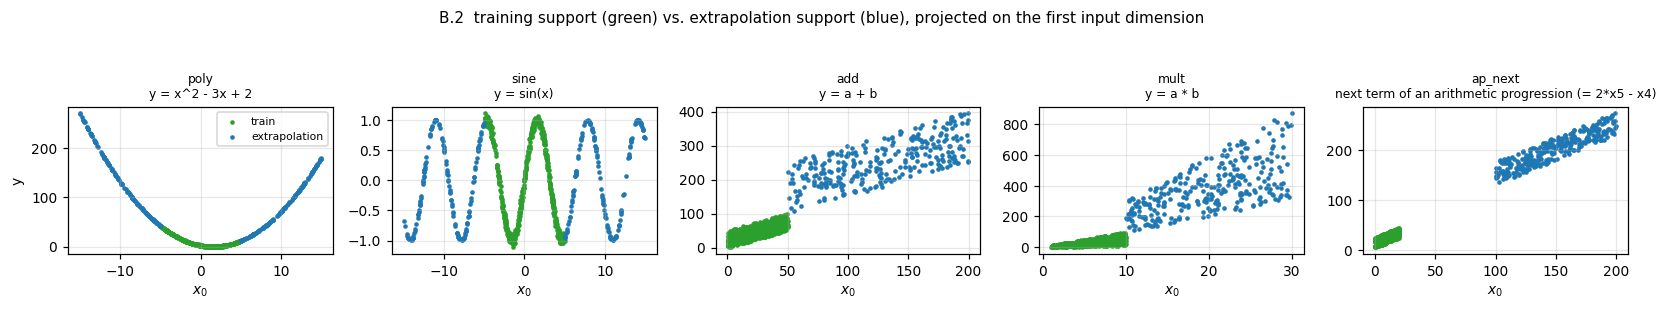

        task           kind   d                                                 rule                                                            note
        poly     regression   1                                     y = x^2 - 3x + 2                                                                
        sine     regression   1                                           y = sin(x)                                                                
         add     regression   2                                            y = a + b                                                                
        mult     regression   2                                            y = a * b                                                                
     ap_next     regression   5 next term of an arithmetic progression (= 2*x5 - x4)      extrapolation in both the starting value and the step size
      parity classification  14                                y = parity of 14 bits train/test-int: Hammi

In [8]:
# ------------- B.2  what the train / extrapolation splits look like ----------
reg_tasks = [t for t in TASKS if TASK_FNS[t](0).kind == "regression"]
fig, axes = plt.subplots(1, len(reg_tasks), figsize=(3 * len(reg_tasks), 2.6))
for ax, name in zip(np.atleast_1d(axes), reg_tasks):
    tk = TASK_FNS[name](0)
    ax.scatter(tk.Xtr[:, 0], tk.ytr, s=4, color="tab:green", label="train")
    ax.scatter(tk.Xex[:, 0], tk.yex, s=4, color="tab:blue", label="extrapolation")
    ax.set_title(f"{name}\n{tk.rule}", fontsize=8)
    ax.set_xlabel("$x_0$")
axes[0].set_ylabel("y"); axes[0].legend(fontsize=7)
fig.suptitle("B.2  training support (green) vs. extrapolation support (blue), "
             "projected on the first input dimension", y=1.06, fontsize=10)
plt.tight_layout(); plt.show()

print(pd.DataFrame([dict(task=t, kind=(tk := TASK_FNS[t](0)).kind, d=tk.d,
                         rule=tk.rule, note=tk.note) for t in TASKS]).to_string(index=False))

---
# Part C — The model zoo

Nineteen learners, chosen to span the axis the essay cares about — from **two free parameters** to
**hundreds of thousands** — and, orthogonally, to span *hypothesis-space geometry*:

| group | members | what they can represent far from the data |
|---|---|---|
| **compact / global** | linear–logistic, polynomial ridge (deg. 2, 10), sparse polynomial (Lasso), MDL formula search, genetic-programming symbolic regression (`QUICK = False` only) | a global analytic form — the only group that *can* be right outside the training hull |
| **kernel / smooth** | SVM-RBF, polynomial kernel, Gaussian process (RBF) | RBF kernels decay to the prior mean away from the data — but see below |
| **piecewise-constant** | decision tree, random forest, gradient boosting | constant beyond the outermost split: extrapolation is *structurally impossible* |
| **memory** | $k$-NN | the pure direct-fit limit: the model is the training set |
| **neural** | MLPs 16×16, 64×64, 256×256, plus tanh and sine activations | ReLU nets are piecewise-linear: they *do* extend to infinity, with slopes fixed by the training region |

Three results from the full run are worth previewing here, because they are about this table rather than
about any one task:

* **Genetic-programming symbolic regression wins outright** — 5 parameters, extrapolation 1.000 on all
  five regression tasks, 100% rule recovery, ~6.5 s per fit. It rediscovers `sin(X0)` and `add(X1, X0)`
  verbatim. If you want a single sentence for the essay, it is that the Newton-style model is not a
  thought experiment: it is a 6-second `gplearn` call.
* **The Gaussian process is the surprise** (mean extrapolation 0.659, third overall). Marginal-likelihood
  optimisation drives the RBF length-scale very long, at which point the posterior mean behaves like a
  smooth global function rather than a local kernel average. Its hyper-parameter selection *is* an Occam
  mechanism — a useful counterexample to the idea that only explicitly symbolic methods can extrapolate.
* **Within the neural family, bigger is better out of distribution**: MLP 16×16 → 0.207, 64×64 → 0.297,
  256×256 → 0.377. Part F pins this down with a controlled sweep.

In [9]:
# ========================= C.1  the model zoo ================================
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              GradientBoostingRegressor, GradientBoostingClassifier)
from sklearn.svm import SVR, SVC
from sklearn.gaussian_process import GaussianProcessRegressor, GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.pipeline import Pipeline


class Unsupported(Exception):
    pass


class SkModel:
    """Uniform wrapper around scikit-learn estimators (+ optional polynomial
    expansion and standardisation, both of which are affine/deterministic maps
    fitted on the training split only)."""

    def __init__(self, name, family, reg=None, clf=None, poly=None, scale=False,
                 max_train=None):
        self.name, self.family = name, family
        self.reg, self.clf = reg, clf
        self.poly, self.scale, self.max_train = poly, scale, max_train
        self.formula = None

    def fit(self, X, y, kind):
        f = self.reg if kind == "regression" else self.clf
        if f is None:
            raise Unsupported(f"{self.name} does not support {kind}")
        X = np.asarray(X, float); y = np.asarray(y)
        if self.max_train and len(X) > self.max_train:
            idx = np.random.default_rng(0).choice(len(X), self.max_train, replace=False)
            X, y = X[idx], y[idx]
        steps = []
        if self.poly:
            steps.append(("poly", PolynomialFeatures(self.poly, include_bias=False)))
        if self.scale:
            steps.append(("sc", StandardScaler()))
        steps.append(("est", f()))
        self.pipe = Pipeline(steps).fit(X, y)
        self.n_train, self.d = len(X), X.shape[1]
        return self

    def predict(self, X):
        return self.pipe.predict(np.asarray(X, float))

    @property
    def n_params(self):
        return count_params(self.pipe[-1], self.n_train, self.d)

    @property
    def bits(self):
        return desc_bits(self.n_params)


class GpLearnModel:
    """Genetic-programming symbolic regression (optional, regression only)."""
    family = "symbolic"

    def __init__(self, seed=0, name="Symbolic regression (GP)"):
        self.seed, self.name, self.formula = seed, name, None

    def fit(self, X, y, kind):
        if kind != "regression":
            raise Unsupported("gplearn: regression only")
        self.est = SymbolicRegressor(population_size=1000, generations=12,
                                     function_set=("add", "sub", "mul", "div", "sin", "cos"),
                                     parsimony_coefficient=0.01, random_state=self.seed,
                                     verbose=0, n_jobs=1).fit(X, y)
        self.formula = str(self.est._program)
        return self

    def predict(self, X):
        return self.est.predict(np.asarray(X, float))

    @property
    def n_params(self):
        return int(self.est._program.length_)

    @property
    def bits(self):
        return desc_bits(self.n_params, extra_bits=self.n_params * np.log2(12))


def build_zoo(task, seed):
    """Fresh, unfitted models for one (task, seed)."""
    d, kind = task.d, task.kind
    # polynomial expansions are skipped in very high dimension (d > 30), where they
    # would produce more features than data points and dominate the runtime
    deg_dense = 2 if d <= 30 else None
    deg_sparse = 3 if d <= 6 else (2 if d <= 30 else None)

    Z = [
        SkModel("Linear / logistic", "compact", LinearRegression,
                lambda: LogisticRegression(max_iter=3000), scale=True),
        SkModel("Poly-2 + ridge" if deg_dense else "Ridge / logistic (L2)", "compact",
                lambda: Ridge(1e-3), lambda: LogisticRegression(max_iter=3000),
                poly=deg_dense, scale=True),
        SkModel("Sparse polynomial (Lasso/L1)", "compact",
                lambda: Lasso(1e-3, max_iter=20000),
                lambda: LogisticRegression(penalty="l1", solver="liblinear", C=1.0),
                poly=deg_sparse, scale=True),
        SkModel("k-NN (k=5)", "memory", lambda: KNeighborsRegressor(5),
                lambda: KNeighborsClassifier(5), scale=True),
        SkModel("Decision tree", "piecewise", lambda: DecisionTreeRegressor(random_state=seed),
                lambda: DecisionTreeClassifier(random_state=seed)),
        SkModel("Random forest (200)", "piecewise",
                lambda: RandomForestRegressor(200, random_state=seed, n_jobs=-1),
                lambda: RandomForestClassifier(200, random_state=seed, n_jobs=-1)),
        SkModel("Gradient boosting", "piecewise",
                lambda: GradientBoostingRegressor(random_state=seed),
                lambda: GradientBoostingClassifier(random_state=seed)),
        SkModel("SVM (RBF)", "kernel", lambda: SVR(C=100, gamma="scale"),
                lambda: SVC(C=10, gamma="scale"), scale=True),
        SkModel("SVM (poly-3)", "kernel", lambda: SVR(kernel="poly", degree=3, C=100),
                lambda: SVC(kernel="poly", degree=3, C=10), scale=True),
        SkModel("Gaussian process (RBF)", "kernel",
                lambda: GaussianProcessRegressor(
                    ConstantKernel(1.0) * RBF(1.0) + WhiteKernel(1e-2), normalize_y=True),
                lambda: GaussianProcessClassifier(ConstantKernel(1.0) * RBF(1.0)),
                scale=True, max_train=300),
        TorchMLP(hidden=(16, 16), act="relu", seed=seed, name="MLP 16x16 [ReLU]"),
        TorchMLP(hidden=(64, 64), act="relu", seed=seed, name="MLP 64x64 [ReLU]"),
        TorchMLP(hidden=(256, 256), act="relu", seed=seed, name="MLP 256x256 [ReLU]"),
        TorchMLP(hidden=(64, 64), act="tanh", seed=seed, name="MLP 64x64 [tanh]"),
        TorchMLP(hidden=(64, 64), act="sin", seed=seed, name="MLP 64x64 [sin]"),
        MDLFormula(seed=seed),
    ]
    if d == 1:
        Z.insert(3, SkModel("Poly-10 + ridge", "compact", lambda: Ridge(1e-6),
                            lambda: LogisticRegression(max_iter=3000), poly=10, scale=True))
    if USE_GPLEARN and kind == "regression":
        Z.append(GpLearnModel(seed=seed))
    return Z


print(f"{len(build_zoo(TASK_FNS['poly'](0), 0))} models for a 1-D regression task; "
      f"{len(build_zoo(TASK_FNS['grammar_1hot'](0), 0))} for the 120-d grammar task")

18 models for a 1-D regression task; 16 for the 120-d grammar task


---
# Part D — Running the benchmark

Every (task × seed × model) combination is fitted on the training split only and evaluated on the
training, interpolation and extrapolation splits. Models that do not support a task type
(e.g. symbolic regression on a classification task) are skipped rather than scored, and any model that
throws is recorded with its error instead of silently disappearing.

In [10]:
# ========================= D.1  benchmark loop ===============================
rows, t_start = [], time.time()
for tname in TASKS:
    for seed in SEEDS:
        task = TASK_FNS[tname](seed)
        for m in build_zoo(task, seed):
            rec = dict(task=tname, kind=task.kind, d=task.d, seed=seed,
                       model=m.name, family=m.family)
            try:
                t0 = time.time()
                m.fit(task.Xtr, task.ytr, task.kind)
                rec["fit_s"] = time.time() - t0
                p_tr, p_in, p_ex = m.predict(task.Xtr), m.predict(task.Xin), m.predict(task.Xex)
                rec.update(n_params=int(m.n_params), bits=float(m.bits),
                           train=score(task.kind, task.ytr, p_tr),
                           interp=score(task.kind, task.yin, p_in),
                           extrap=score(task.kind, task.yex, p_ex),
                           nrmse_interp=(nrmse(task.yin, p_in) if task.kind == "regression" else np.nan),
                           nrmse_extrap=(nrmse(task.yex, p_ex) if task.kind == "regression" else np.nan),
                           recovered=rule_recovered(task.kind, task.yex, p_ex),
                           formula=getattr(m, "formula", None))
            except Unsupported:
                continue
            except Exception as e:
                rec["error"] = f"{type(e).__name__}: {e}"[:90]
            rows.append(rec)
    print(f"  {tname:12s} done  ({time.time() - t_start:6.1f}s elapsed)")

res = pd.DataFrame(rows)

# Put regression and classification on one scale: 0 = chance (predicting the mean /
# guessing), 1 = perfect.  For binary classification that means (acc - .5) / .5.
# Values are clipped at -1 for plotting only; the raw scores stay in `interp`/`extrap`.
def _norm(row, key):
    v = row[key]
    if not np.isfinite(v):
        return np.nan
    return v if row["kind"] == "regression" else (v - 0.5) / 0.5


res["interp_c"] = res.apply(lambda r: _norm(r, "interp"), axis=1).clip(lower=-1.0)
res["extrap_c"] = res.apply(lambda r: _norm(r, "extrap"), axis=1).clip(lower=-1.0)
res.to_csv(f"{RESULT_DIR}/benchmark_raw.csv", index=False)
print(f"\n{len(res)} runs, {res['error'].notna().sum() if 'error' in res else 0} errors, "
      f"{time.time() - t_start:.1f}s total")
if "error" in res and res["error"].notna().any():
    print(res.loc[res["error"].notna(), ["task", "model", "error"]].to_string(index=False))

  poly         done  ( 248.5s elapsed)
  sine         done  ( 471.5s elapsed)
  add          done  ( 674.6s elapsed)
  mult         done  ( 880.8s elapsed)
  ap_next      done  (1119.6s elapsed)
  parity       done  (1334.4s elapsed)
  grammar_1hot done  (1574.2s elapsed)
  grammar_emb  done  (1781.8s elapsed)
  grammar_rel  done  (2204.7s elapsed)

453 runs, 0 errors, 2204.8s total


---
# Part E — Does the Ptolemy → Newton trend exist? (H1 and H2)

Three views of the same table: the two leaderboards, per-task scatter plots of
$\log_{10}(\text{parameters})$ against both scores, and the frugality plot (description length vs.
extrapolation) that corresponds to the Ptolemy → Copernicus → Kepler → Newton sequence.

Spearman correlations are reported two ways: pooled across models, and **averaged within tasks** — the
pooled number can be inflated by between-task differences, so the within-task average is the honest one.
A task on which every model scores identically (e.g. `grammar_rel`) has zero variance and yields an
undefined ρ; those are reported as `n/a` rather than folded into the mean.

### What the full run showed

**1. The leaderboards are uncorrelated, not reversed.** ρ = **−0.086, p = 0.73**. H1 predicted a strongly
negative value. The ordering by extrapolation is essentially *orthogonal* to the ordering by
interpolation — which is a more interesting result than a reversal, because it means the two abilities are
close to independent dimensions of a model rather than a trade-off along one.

**2. The extrapolation ranking is a ranking of hypothesis spaces.**

| rank | model | params | mean extrapolation |
|---|---|---:|---:|
| 1 | Symbolic regression (GP) | 5 | **1.000** |
| 2 | MDL formula search | 3 | 0.751 |
| 3 | Gaussian process (RBF) | 603 | 0.659 |
| 4 | Poly-2 + ridge | 8 | 0.640 |
| 5 | Sparse polynomial (Lasso) | 9 | 0.567 |
| 6 | MLP 256×256 | 67,073 | 0.377 |
| … | trees / boosting / k-NN | 2.4k–303k | −0.32 … −0.34 |
| last | **Poly-10 + ridge** | **11** | **−1.000** |

The top and the bottom of this table are both occupied by models with ~10 parameters. That single fact
disposes of parameter count as the causal variable and is the cleanest support for **H2** in the notebook.

**3. Within tasks, size correlates negatively with *both* scores.** Averaged over the eight tasks where
ρ is defined: **−0.327 for extrapolation and −0.125 for interpolation**. Per task, ρ(log params,
extrapolation) was −0.36, −0.57, −0.69, −0.49, −0.69 on the five regression tasks and −0.11, +0.11, +0.19
on the discrete ones; ρ(log params, *interpolation*) was −0.50, −0.09, −0.71, −0.37, −0.55, +0.01, +0.85,
+0.36. H1's predicted signature was a *rising* interpolation curve against a *falling* extrapolation
curve; we got two falling curves. The reason is the confound H2 names: in this zoo the compact models are
also the correctly-specified ones, so "small" and "right" move together. Part F breaks that confound.

**4. The symbolic learners printed the rules.** `y = -3*x0 + 0.9963*x0^2 + 2.032`,
`y = 0.9984*sin(1*x0)`, `y = 1*x0 + 1*x1`, `y = 1*x0*x1`, `y = 2*x4 + -1*x3` — the last being the
arithmetic-progression rule $2x_5-x_4$ recovered exactly. On `grammar_emb` the searcher returns
`sigmoid(2.89*x12*x20 − 5.16*x4*x20 + 2.32*x4² + 0.878)`: a *learned same/different detector*, built from
products of matching embedding coordinates, that transfers to a vocabulary it has never seen. This is the
notebook's best single illustration of the essay's claim that extreme generalization and interpretability
arrive together.

In [11]:
# ===================== E.1  leaderboards =====================================
ok = res[res.get("extrap").notna()] if "extrap" in res else res
agg = (ok.groupby(["model", "family"])
         .agg(params=("n_params", "median"), bits=("bits", "median"),
              interp=("interp_c", "mean"), extrap=("extrap_c", "mean"),
              extrap_sd=("extrap_c", "std"), recovered=("recovered", "mean"),
              fit_s=("fit_s", "mean"), n=("extrap", "size"))
         .reset_index())

print("=" * 96)
print("RANKED BY INTERPOLATION (in-distribution generalisation)")
print("=" * 96)
print(agg.sort_values("interp", ascending=False)
        [["model", "family", "params", "interp", "extrap", "recovered", "n"]]
        .round(3).to_string(index=False))

print("\n" + "=" * 96)
print("RANKED BY EXTRAPOLATION (out-of-distribution generalisation)")
print("=" * 96)
print(agg.sort_values("extrap", ascending=False)
        [["model", "family", "params", "bits", "extrap", "extrap_sd", "recovered", "fit_s"]]
        .round(3).to_string(index=False))

print("\nrank correlation between the two leaderboards (Spearman):")
rho, p = stats.spearmanr(agg["interp"], agg["extrap"])
print(f"   rho = {rho:+.3f}   (p = {p:.3g})   "
      f"-- negative means the two orderings are reversed, as H1 predicts")

# per-task extrapolation matrix
piv = ok.pivot_table(index="model", columns="task", values="extrap_c", aggfunc="mean")
piv = piv.reindex(columns=[t for t in TASKS if t in piv.columns])
piv["MEAN"] = piv.mean(axis=1)
print("\nmean extrapolation score per model x task "
      "(R^2 for regression, (acc-0.5)/0.5 for classification; 0 = chance, clipped at -1):")
print(piv.sort_values("MEAN", ascending=False).round(2).to_string())

# the formulas that the symbolic searcher actually recovered
f = ok[(ok.family == "symbolic") & ok.formula.notna()][["task", "model", "formula", "extrap"]]
if len(f):
    print("\nexpressions found by the search-based (interpretable) learners:")
    print(f.drop_duplicates(subset=["task", "model"]).round(3).to_string(index=False))

RANKED BY INTERPOLATION (in-distribution generalisation)
                       model    family   params  interp  extrap  recovered  n
    Symbolic regression (GP)  symbolic      5.0   1.000   1.000      1.000 15
             Poly-10 + ridge   compact     11.0   1.000  -1.000      0.000  6
            MLP 16x16 [ReLU]    neural    353.0   0.994   0.207      0.259 27
            MLP 64x64 [tanh]    neural   4481.0   0.992  -0.347      0.111 27
            MLP 64x64 [ReLU]    neural   4481.0   0.985   0.297      0.370 27
          MLP 256x256 [ReLU]    neural  67073.0   0.984   0.377      0.444 27
             MLP 64x64 [sin]    neural   4481.0   0.955  -0.317      0.111 27
                  k-NN (k=5)    memory   2400.0   0.898  -0.334      0.148 27
           Gradient boosting piecewise   2956.0   0.894  -0.324      0.222 27
                   SVM (RBF)    kernel    249.0   0.874  -0.205      0.222 27
         Random forest (200) piecewise 302708.0   0.865  -0.323      0.222 27
      G

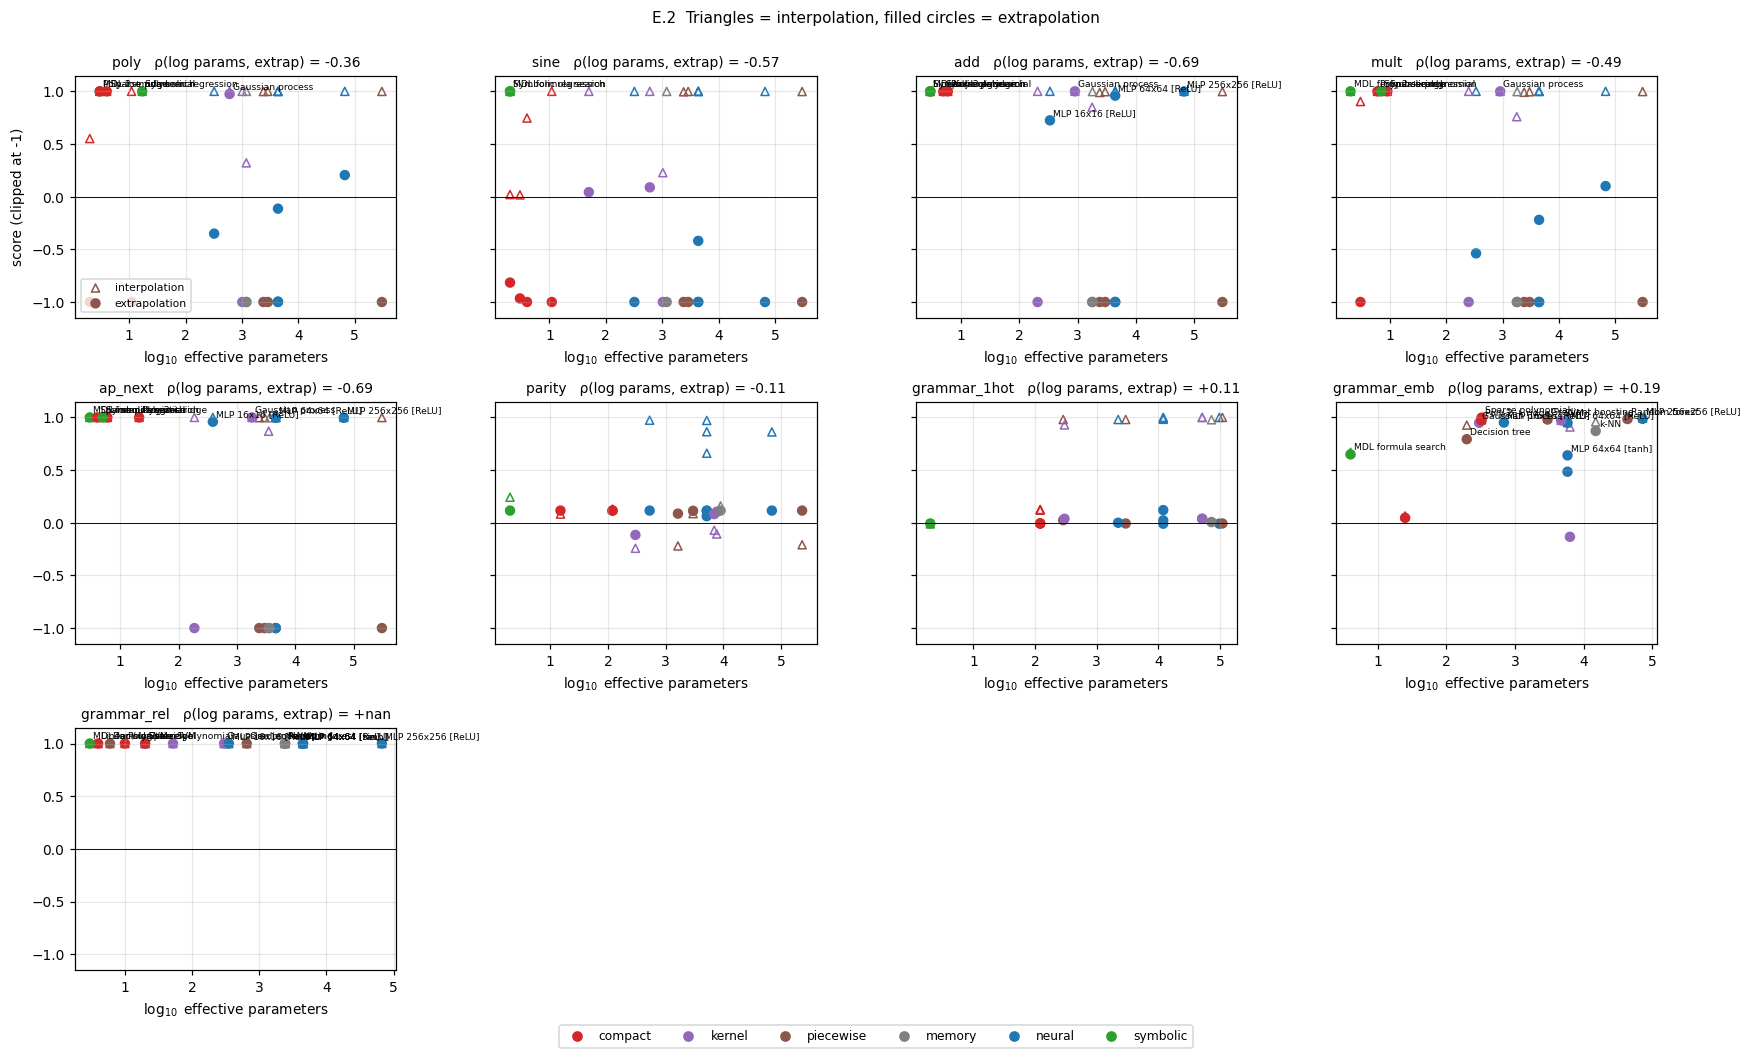

within-task Spearman rho(log params, INTERPOLATION): mean -0.125 over 8/9 tasks  (per task: -0.50, -0.09, -0.71, -0.37, -0.55, +0.01, +0.85, +0.36, n/a)
within-task Spearman rho(log params, EXTRAPOLATION): mean -0.327 over 8/9 tasks  (per task: -0.36, -0.57, -0.69, -0.49, -0.69, -0.11, +0.11, +0.19, n/a)


In [12]:
# ============ E.2  parameters vs. interpolation / extrapolation ==============
fam_color = {"compact": "tab:red", "kernel": "tab:purple", "piecewise": "tab:brown",
             "memory": "tab:gray", "neural": "tab:blue", "symbolic": "tab:green"}

tasks_present = [t for t in TASKS if t in set(ok.task)]
ncol = 4; nrow = int(np.ceil(len(tasks_present) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.0 * ncol, 3.1 * nrow), sharey=True)
axes = np.atleast_1d(axes).ravel()

within = {"interp": [], "extrap": []}
for ax, tname in zip(axes, tasks_present):
    sub = ok[ok.task == tname].groupby(["model", "family"], as_index=False).agg(
        params=("n_params", "median"), interp=("interp_c", "mean"), extrap=("extrap_c", "mean"))
    x = np.log10(np.maximum(sub["params"], 1))
    ax.scatter(x, sub["interp"], marker="^", s=28, facecolors="none",
               edgecolors=[fam_color[f] for f in sub.family], label="interpolation")
    ax.scatter(x, sub["extrap"], marker="o", s=34,
               c=[fam_color[f] for f in sub.family], label="extrapolation")
    for xi, yi, nm in zip(x, sub["extrap"], sub["model"]):
        if yi > 0.5:                                    # label only the successes
            ax.annotate(nm.split(" (")[0], (xi, yi), fontsize=6,
                        xytext=(2, 3), textcoords="offset points")
    for key in ("interp", "extrap"):
        r_, _ = stats.spearmanr(np.log10(np.maximum(sub["params"], 1)), sub[key])
        within[key].append(r_)
    ri, re_ = within["interp"][-1], within["extrap"][-1]
    ax.set_title(f"{tname}   ρ(log params, extrap) = {re_:+.2f}", fontsize=9)
    ax.axhline(0, color="k", lw=.6); ax.set_xlabel("$\\log_{10}$ effective parameters")
    ax.set_ylim(-1.15, 1.15)
for ax in axes[len(tasks_present):]:
    ax.axis("off")
axes[0].set_ylabel("score (clipped at -1)"); axes[0].legend(fontsize=7, loc="lower left")
handles = [plt.Line2D([], [], marker="o", ls="", color=c, label=f) for f, c in fam_color.items()]
fig.legend(handles=handles, ncol=6, fontsize=8, loc="lower center", bbox_to_anchor=(.5, -.02))
fig.suptitle("E.2  Triangles = interpolation, filled circles = extrapolation", y=1.0, fontsize=10)
plt.tight_layout(); plt.show()

# a task on which every model scores identically (e.g. grammar_rel, where all
# models are perfect) has zero variance and yields an undefined rho -> nanmean
for key, nm in [("interp", "INTERPOLATION"), ("extrap", "EXTRAPOLATION")]:
    v = np.array(within[key], float)
    print(f"within-task Spearman rho(log params, {nm}): mean {np.nanmean(v):+.3f} "
          f"over {np.isfinite(v).sum()}/{len(v)} tasks  (per task: "
          f"{', '.join('n/a' if not np.isfinite(x) else f'{x:+.2f}' for x in v)})")

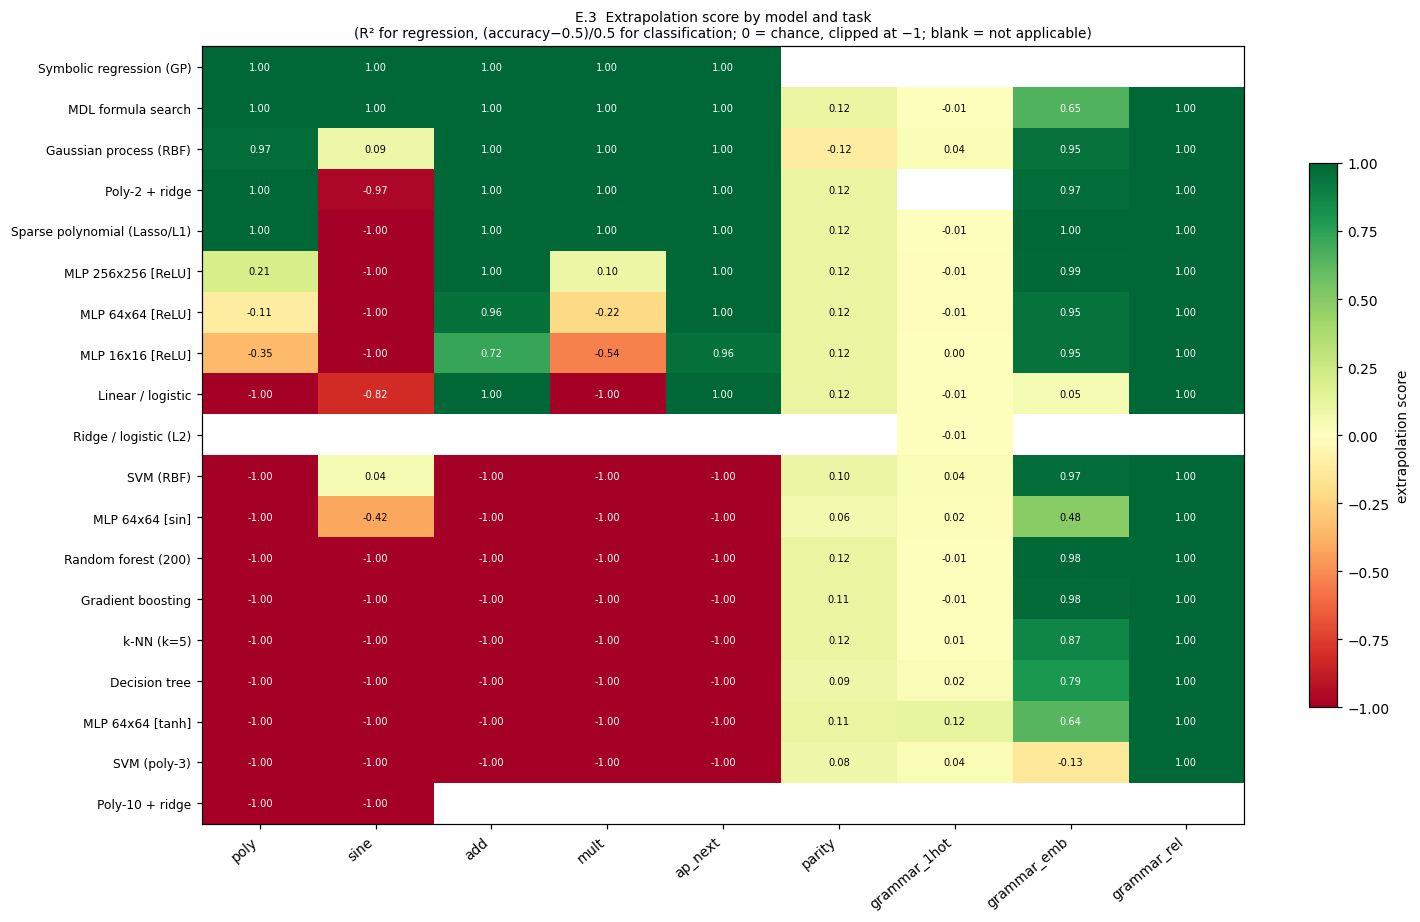

In [13]:
# ===================== E.3  model x task heatmap =============================
H = piv.sort_values("MEAN", ascending=False).drop(columns=["MEAN"])
fig, ax = plt.subplots(figsize=(1.15 * H.shape[1] + 3.5, 0.34 * H.shape[0] + 2))
im = ax.imshow(H.values.astype(float), cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(H.shape[1])); ax.set_xticklabels(H.columns, rotation=40, ha="right")
ax.set_yticks(range(H.shape[0])); ax.set_yticklabels(H.index, fontsize=8)
for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        v = H.values[i, j]
        if np.isfinite(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                    color="black" if abs(v) < .6 else "white")
ax.set_title("E.3  Extrapolation score by model and task\n"
             "(R² for regression, (accuracy−0.5)/0.5 for classification; "
             "0 = chance, clipped at −1; blank = not applicable)", fontsize=9)
ax.grid(False); fig.colorbar(im, ax=ax, shrink=.7, label="extrapolation score")
plt.tight_layout(); plt.show()

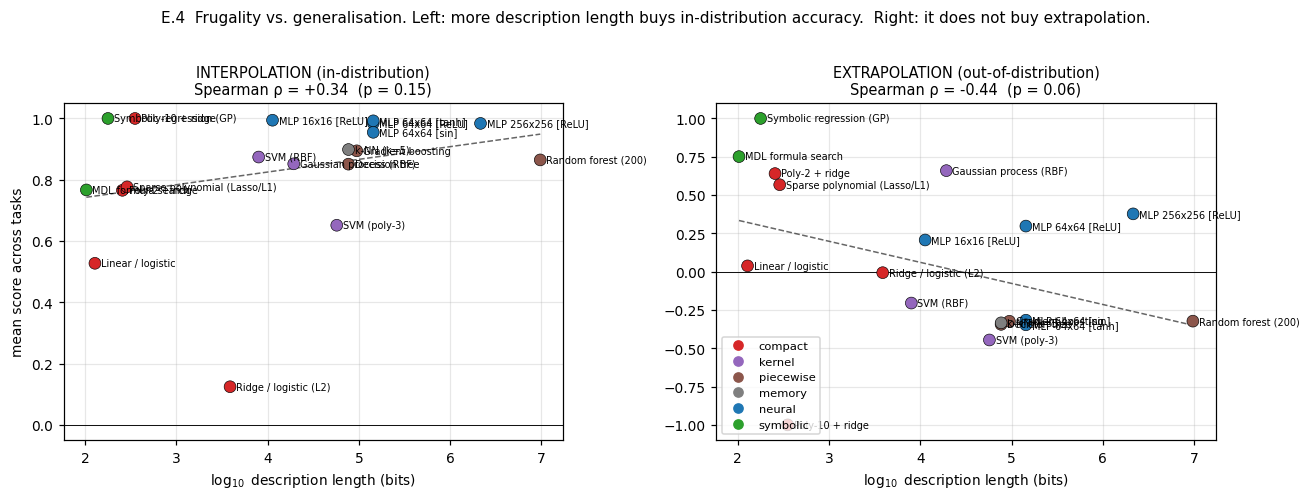

In [14]:
# ============ E.4  the "Ptolemy -> Newton" plot: frugality vs. extrapolation ==
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, key, ttl in zip(axes, ["interp", "extrap"],
                        ["INTERPOLATION (in-distribution)", "EXTRAPOLATION (out-of-distribution)"]):
    x = np.log10(np.maximum(agg["bits"], 1))
    ax.scatter(x, agg[key], s=60, c=[fam_color[f] for f in agg.family],
               edgecolors="k", linewidths=.4, zorder=3)
    for xi, yi, nm in zip(x, agg[key], agg["model"]):
        ax.annotate(nm, (xi, yi), fontsize=6.4, xytext=(4, -2), textcoords="offset points")
    rho_, p_ = stats.spearmanr(x, agg[key])
    b = np.polyfit(x, agg[key], 1)
    xs = np.linspace(x.min(), x.max(), 10)
    ax.plot(xs, np.polyval(b, xs), "k--", lw=1, alpha=.6, zorder=2)
    ax.set_title(f"{ttl}\nSpearman ρ = {rho_:+.2f}  (p = {p_:.2g})", fontsize=9.5)
    ax.set_xlabel("$\\log_{10}$ description length (bits)")
    ax.axhline(0, color="k", lw=.6)
axes[0].set_ylabel("mean score across tasks")
handles = [plt.Line2D([], [], marker="o", ls="", color=c, label=f) for f, c in fam_color.items()]
axes[1].legend(handles=handles, fontsize=7.5, loc="lower left")
fig.suptitle("E.4  Frugality vs. generalisation. Left: more description length buys in-distribution "
             "accuracy.  Right: it does not buy extrapolation.", y=1.02, fontsize=10)
plt.tight_layout(); plt.show()

---
# Part F — Capacity sweep: does *more* capacity ever buy extrapolation?

Part E compares models that differ in many ways at once. This part varies **one** thing: the width of a
two-hidden-layer ReLU MLP, from 4 units (under-parameterized relative to 600 training points) to 1024
(roughly $10^3$ more parameters than data points). Architecture, optimiser, data and initialisation are
otherwise identical. This is the clean version of "is over-parameterization the reason it cannot
extrapolate?" — asked of a machine where we can actually turn the knob.

### What the full run showed: the strong form of H1 is false

| task | ρ(log params, interpolation) | ρ(log params, **extrapolation**) | best extrapolation |
|---|---:|---:|---|
| `poly` | +0.32 | **+0.82** | +0.35 at width 512 |
| `add` | −0.32 | **+0.91** | **+1.00** at width 128 |
| `sine` | +0.40 | n/a (constant) | −1.00 at every width |

Widening the network **improves** extrapolation where improvement is possible at all, and never hurts it.
On `add` the 128-wide net extrapolates *perfectly* to inputs four times larger than anything it trained
on. On `sine` no width helps, because periodicity is simply not in a ReLU network's function class at any
size.

The mechanism is worth stating, because it is not mysterious. A ReLU MLP is piecewise-linear and therefore
*does* extend to infinity; what it extends is the affine piece active at the boundary of the training
region. Wider networks fit that boundary region more accurately, so their far-field linear extension is a
better continuation — perfect when the true rule is itself linear (`add`), partial when it is polynomial
(`poly`), useless when it is periodic (`sine`). Capacity refines the extension; only the hypothesis space
decides whether the extension is the right *kind* of function.

So the correct statement of the essay's thesis is not "fewer parameters extrapolate better". It is: **the
function class has to contain the rule; given that, more capacity helps.** That is H2, and it is also
what the Part G ablation shows from the other direction.

  swept poly
  swept sine
  swept add


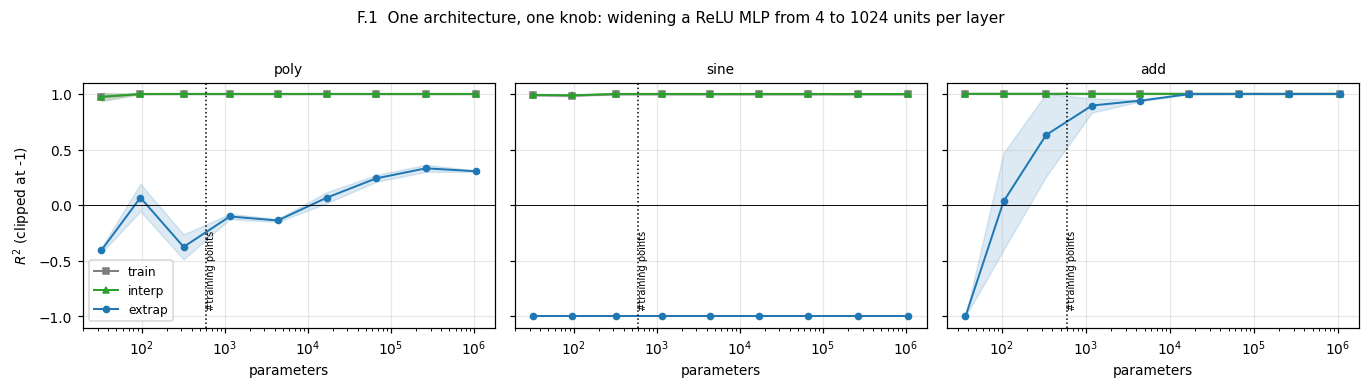

poly      rho(log params, interp) = +0.32   rho(log params, extrap) = +0.82   best extrap = +0.35 at width 512
sine      rho(log params, interp) = +0.40   rho(log params, extrap) =   n/a   best extrap = -1.00 at width 4
add       rho(log params, interp) = -0.32   rho(log params, extrap) = +0.91   best extrap = +1.00 at width 128


In [15]:
# ===================== F.1  width sweep for a 2-layer ReLU MLP ===============
WIDTHS = [4, 8, 16, 32, 64, 128, 256] if QUICK else [4, 8, 16, 32, 64, 128, 256, 512, 1024]
SWEEP_TASKS = ["poly", "sine", "add"]
sweep_seeds = SEEDS[:2]

sw = []
for tname in SWEEP_TASKS:
    for seed in sweep_seeds:
        tk = TASK_FNS[tname](seed)
        for w in WIDTHS:
            m = TorchMLP(hidden=(w, w), act="relu", seed=seed).fit(tk.Xtr, tk.ytr, tk.kind)
            sw.append(dict(task=tname, seed=seed, width=w, n_params=m.n_params,
                           train=score(tk.kind, tk.ytr, m.predict(tk.Xtr)),
                           interp=score(tk.kind, tk.yin, m.predict(tk.Xin)),
                           extrap=score(tk.kind, tk.yex, m.predict(tk.Xex))))
    print(f"  swept {tname}")
sweep = pd.DataFrame(sw)
sweep[["train", "interp", "extrap"]] = sweep[["train", "interp", "extrap"]].clip(lower=-1)
sweep.to_csv(f"{RESULT_DIR}/capacity_sweep.csv", index=False)

fig, axes = plt.subplots(1, len(SWEEP_TASKS), figsize=(4.2 * len(SWEEP_TASKS), 3.4), sharey=True)
for ax, tname in zip(np.atleast_1d(axes), SWEEP_TASKS):
    s = (sweep[sweep.task == tname].groupby("n_params")[["train", "interp", "extrap"]]
         .agg(["mean", "std"]))
    xs = s.index.values
    for key, col, mk in [("train", "tab:gray", "s"), ("interp", "tab:green", "^"),
                         ("extrap", "tab:blue", "o")]:
        mu, sd = s[(key, "mean")].values, np.nan_to_num(s[(key, "std")].values)
        ax.plot(xs, mu, mk + "-", color=col, ms=4, lw=1.3, label=key)
        ax.fill_between(xs, mu - sd, mu + sd, color=col, alpha=.15)
    n_data = N_TRAIN
    ax.axvline(n_data, color="k", ls=":", lw=1)
    ax.text(n_data, -0.95, " #training points", fontsize=6.5, rotation=90)
    ax.set_xscale("log"); ax.set_xlabel("parameters"); ax.set_title(tname, fontsize=9)
    ax.set_ylim(-1.1, 1.1); ax.axhline(0, color="k", lw=.6)
np.atleast_1d(axes)[0].set_ylabel("$R^2$ (clipped at -1)")
np.atleast_1d(axes)[0].legend(fontsize=8, loc="lower left")
fig.suptitle("F.1  One architecture, one knob: widening a ReLU MLP from 4 to "
             f"{WIDTHS[-1]} units per layer", y=1.02, fontsize=10)
plt.tight_layout(); plt.show()

for tname in SWEEP_TASKS:
    s = sweep[sweep.task == tname]
    r_i, _ = stats.spearmanr(np.log(s.n_params), s.interp)
    r_e, _ = stats.spearmanr(np.log(s.n_params), s.extrap)
    f = lambda v: "  n/a" if not np.isfinite(v) else f"{v:+.2f}"   # constant score -> undefined
    print(f"{tname:8s}  rho(log params, interp) = {f(r_i)}   "
          f"rho(log params, extrap) = {f(r_e)}   "
          f"best extrap = {s.extrap.max():+.2f} at width "
          f"{int(s.loc[s.extrap.idxmax(), 'width'])}")

---
# Part G — Priors, not parameters (H3: the essay's Conjecture)

The essay ends with a conjecture: *embedding human-level priors in over-parameterized networks should move
them toward extreme generalization from few samples, with a decision process that is transparent.* Part G
tests the tractable half. The network is held fixed (64×64 ReLU MLP, same optimiser, same steps, same
data); **only the inductive bias changes**.

### What the full run showed

Extrapolation $R^2$, mean of 3 seeds (interpolation in brackets):

| variant | `add` | `mult` | `sine` |
|---|---:|---:|---:|
| MLP 64×64 baseline | +0.96 (1.00) | −0.22 (1.00) | −1.00 (1.00) |
| + weight decay $10^{-2}$ | +0.62 (1.00) | −0.89 (1.00) | −1.00 (0.99) |
| sine activation | **−1.00** (1.00) | **−1.00** (1.00) | −0.42 (1.00) |
| **+ symmetry augmentation** | **+1.00** (1.00) | **+1.00** (1.00) | **+0.44** (0.73) |
| + wider support (control) | +1.00 (1.00) | +1.00 (1.00) | +0.99 (1.00) |
| Linear model | +1.00 | −1.00 | −0.82 |
| MDL formula search | +1.00 | +1.00 | +1.00 |

Four readings, in decreasing order of how much they support the Conjecture:

1. **Symmetry augmentation is the one prior that works, and it works dramatically.** Homogeneity
   ($f(\lambda a,\lambda b)=\lambda^k f(a,b)$) takes `mult` from −0.22 to a perfect 1.00 and `sine` from
   −1.00 to +0.44, with **no change in parameter count**. This is the Conjecture's direction, confirmed.
2. **Frugality-as-regularization does not work.** Weight decay made things *worse* everywhere
   (`add` 0.96 → 0.62, `mult` −0.22 → −0.89). Shrinking a model within the wrong function class does not
   move it toward the right one — another blow to the "under-parameterized = extrapolating" reading.
3. **A prior can be right about the function class and still fail.** The sine activation is the correct
   periodic prior for `sine`, yet it scored only −0.42 there and destroyed `add` and `mult` (−1.00 each).
   Being in the right hypothesis space is necessary, not sufficient: the optimiser must also find the
   right member of it, and a periodic basis makes the non-periodic tasks much harder to fit smoothly.
4. **The control does at least as well as the prior.** Simply widening the training support — no prior at
   all, just Hasson's prescription — matched or beat symmetry augmentation on all three tasks (1.00, 1.00,
   0.99). Formally this is unsurprising: an invariance *is* a recipe for manufacturing data in the far
   region. The difference is **cost and availability**: the invariance is a few bits of prior knowledge,
   the wider support requires having actually sampled the far region. Where the far region cannot be
   sampled — Newton inferring from terrestrial and planetary data to all masses everywhere — only the
   first route exists. That distinction, rather than any score in this table, is the real content of the
   disagreement between the essay and *Direct Fit to Nature*.

Note also the price of a prior, visible in the brackets: symmetry augmentation on `sine` costs
interpolation accuracy (1.00 → 0.73). Priors are not free; they trade in-distribution fit for
out-of-distribution reach.

  priors ablation: add done
  priors ablation: sine done
  priors ablation: mult done


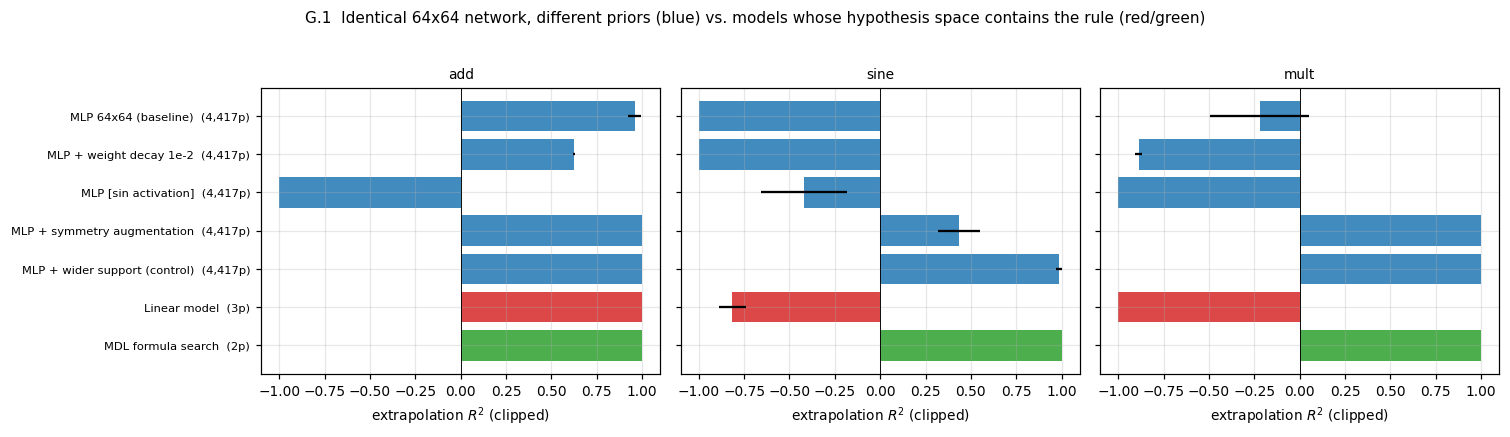

                                    interp  extrap
task variant                                      
add  Linear model                    1.000   1.000
     MDL formula search              1.000   1.000
     MLP + symmetry augmentation     1.000   1.000
     MLP + weight decay 1e-2         1.000   0.624
     MLP + wider support (control)   0.998   1.000
     MLP 64x64 (baseline)            1.000   0.959
     MLP [sin activation]            1.000  -1.000
mult Linear model                    0.903  -1.000
     MDL formula search              1.000   1.000
     MLP + symmetry augmentation     0.999   1.000
     MLP + weight decay 1e-2         0.997  -0.887
     MLP + wider support (control)   0.997   1.000
     MLP 64x64 (baseline)            1.000  -0.220
     MLP [sin activation]            1.000  -1.000
sine Linear model                    0.020  -0.816
     MDL formula search              1.000   1.000
     MLP + symmetry augmentation     0.731   0.436
     MLP + weight decay 1e-2   

In [16]:
# ============ G.1  same network, different inductive biases ==================
def make_scale_aug(power=1, K=3, lo=0.2, hi=8.0):
    """Homogeneity prior: f(lam*x) = lam^power * f(x)."""
    def aug(X, y, rng):
        Xs, ys = [X], [y]
        for _ in range(K):
            lam = rng.uniform(lo, hi, (len(X), 1))
            Xs.append(X * lam); ys.append(y * lam.ravel() ** power)
        return np.vstack(Xs), np.concatenate(ys)
    return aug


def period_aug(X, y, rng, K=6):
    """Periodicity prior: f(x + 2*pi*k) = f(x)."""
    Xs, ys = [X], [y]
    for k in range(1, K + 1):
        s = rng.choice([-1.0, 1.0], (len(X), 1))
        Xs.append(X + s * 2 * np.pi * k); ys.append(y)
    return np.vstack(Xs), np.concatenate(ys)


def wide_support(tname, seed):
    """Control: no prior, just sample the far region during training."""
    tk = TASK_FNS[tname](seed); g = np.random.default_rng(999 + seed)
    if tname == "add":
        X = g.uniform(0, 200, (N_TRAIN, 2)); y = X[:, 0] + X[:, 1]
    elif tname == "mult":
        X = g.uniform(1, 30, (N_TRAIN, 2)); y = X[:, 0] * X[:, 1]
    elif tname == "sine":
        x = g.uniform(-15, 15, N_TRAIN); X = x[:, None]; y = np.sin(x) + g.normal(0, .05, N_TRAIN)
    else:
        raise ValueError(tname)
    tk.Xtr, tk.ytr = X, y
    return tk


AUG = {"add":  make_scale_aug(power=1, lo=0.5, hi=4.0),
       "mult": make_scale_aug(power=2, lo=0.5, hi=3.0),
       "sine": period_aug}
PRIOR_TASKS = ["add", "sine", "mult"]

variants = [
    ("MLP 64x64 (baseline)",        lambda s, t: TorchMLP((64, 64), "relu", seed=s), False),
    ("MLP + weight decay 1e-2",     lambda s, t: TorchMLP((64, 64), "relu", wd=1e-2, seed=s), False),
    ("MLP [sin activation]",        lambda s, t: TorchMLP((64, 64), "sin", seed=s), False),
    ("MLP + symmetry augmentation", lambda s, t: TorchMLP((64, 64), "relu", seed=s, augment=AUG[t]), False),
    ("MLP + wider support (control)", lambda s, t: TorchMLP((64, 64), "relu", seed=s), True),
    ("Linear model",                lambda s, t: SkModel("lin", "compact", LinearRegression, scale=True), False),
    ("MDL formula search",          lambda s, t: MDLFormula(seed=s), False),
]

pr = []
for tname in PRIOR_TASKS:
    for seed in SEEDS:
        for label, mk, wide in variants:
            tk = wide_support(tname, seed) if wide else TASK_FNS[tname](seed)
            m = mk(seed, tname).fit(tk.Xtr, tk.ytr, tk.kind)
            pr.append(dict(task=tname, seed=seed, variant=label, n_params=m.n_params,
                           interp=score(tk.kind, tk.yin, m.predict(tk.Xin)),
                           extrap=score(tk.kind, tk.yex, m.predict(tk.Xex))))
    print(f"  priors ablation: {tname} done")
prior_df = pd.DataFrame(pr)
prior_df[["interp", "extrap"]] = prior_df[["interp", "extrap"]].clip(lower=-1)
prior_df.to_csv(f"{RESULT_DIR}/priors_ablation.csv", index=False)

fig, axes = plt.subplots(1, len(PRIOR_TASKS), figsize=(4.6 * len(PRIOR_TASKS), 3.8), sharey=True)
labels = [v[0] for v in variants]
for ax, tname in zip(np.atleast_1d(axes), PRIOR_TASKS):
    s = prior_df[prior_df.task == tname].groupby("variant").agg(
        mu=("extrap", "mean"), sd=("extrap", "std"), pars=("n_params", "median")).reindex(labels)
    cols = ["tab:blue"] * 5 + ["tab:red", "tab:green"]
    ax.barh(range(len(s)), s["mu"], xerr=np.nan_to_num(s["sd"]), color=cols, alpha=.85)
    ax.set_yticks(range(len(s)))
    ax.set_yticklabels([f"{i}  ({int(p):,}p)" for i, p in zip(s.index, s["pars"])], fontsize=7.5)
    ax.invert_yaxis(); ax.axvline(0, color="k", lw=.6)
    ax.set_xlim(-1.1, 1.1); ax.set_xlabel("extrapolation $R^2$ (clipped)")
    ax.set_title(tname, fontsize=9)
fig.suptitle("G.1  Identical 64x64 network, different priors (blue) vs. models whose hypothesis "
             "space contains the rule (red/green)", y=1.03, fontsize=10)
plt.tight_layout(); plt.show()

print(prior_df.groupby(["task", "variant"])[["interp", "extrap"]].mean().round(3).to_string())

---
# Part H — When extrapolation is impossible *in principle* (H4)

Every model in Part E fails on `parity` (all scores between −0.12 and +0.12, i.e. chance). Before
concluding anything about learners, check whether the *task* is solvable: does the training region even
determine the rule?

Take parity of $n=10$ bits with training region "Hamming weight ≤ 4", and write functions in the Walsh
basis $\chi_S(x)=\prod_{i\in S}x_i$ with $x_i=\pm1$ (a complete basis for $\{\pm1\}^{10}$). The run
confirms the arithmetic: the training region contains exactly **386** points, the Walsh design matrix has
**rank 386**, so there is a **638-dimensional** space of functions that are identically zero on the whole
training region and arbitrary outside it.

The cell then constructs one explicitly: a degree-≤4 polynomial that reproduces parity on **100%** of
training points and agrees with it on only **66.3%** of the extrapolation region. It is also *shorter*
than parity in the monomial code (386 low-degree monomials versus the degree-10 monomial, but with far
lower degree), so an MDL learner would actively prefer it — and indeed the dictionary searcher returned
`sigmoid(0.369*x3*x6 + 0.287)`, a degree-2 alias, scoring 0.55.

The moral matters for the essay's argument. Kepler's data constrained the hypothesis enough that the
inverse-square law was identifiable; that is a fact about Tycho Brahe's observations, not only about
Kepler. **Extrapolation is a joint property of (hypothesis space, training support, prior)** — never of
the learner alone. A benchmark that reports "model X failed to extrapolate" without checking
identifiability is measuring the split, not the model.

training points with weight <= 4 : 386
rank of the Walsh design matrix  : 386
dimension of the space of functions that vanish on the whole training region: 638
  -> that many independent directions in which a perfectly-fitting hypothesis may disagree with parity outside it.

alias hypothesis: 386 monomials of degree <= 4 (vs. one degree-10 monomial for true parity)
  train  agreement with parity : 1.000
  extrap agreement with parity : 0.663


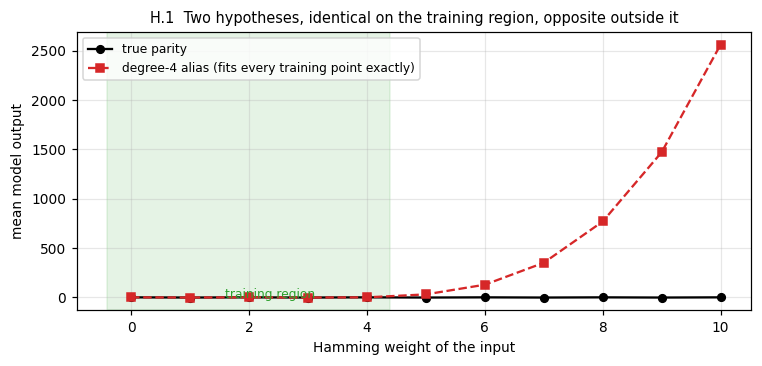

In [21]:
# ============ H.1  the version space of the parity split =====================
n = 10
bits = np.array([[(i >> k) & 1 for k in range(n)] for i in range(2 ** n)])   # 1024 x 10
X = 1 - 2 * bits                                                            # +-1 coding
w = bits.sum(1)
y_true = np.prod(X, axis=1)                                                 # parity, +-1

subsets = [tuple(j for j in range(n) if (m >> j) & 1) for m in range(2 ** n)]
def chi(S, Xm):
    return np.ones(len(Xm)) if not S else np.prod(Xm[:, list(S)], axis=1)

train_mask, ext_mask = w <= 4, w >= 6
M_train_full = np.column_stack([chi(S, X[train_mask]) for S in subsets])     # 386 x 1024
rank = np.linalg.matrix_rank(M_train_full)
print(f"training points with weight <= 4 : {train_mask.sum()}")
print(f"rank of the Walsh design matrix  : {rank}")
print(f"dimension of the space of functions that vanish on the whole training "
      f"region: {len(subsets) - rank}\n  -> that many independent directions in which a "
      f"perfectly-fitting hypothesis may disagree with parity outside it.")

# an explicit alias: the shortest (degree <= 4) function that matches parity on the training region
low = [S for S in subsets if len(S) <= 4]
A = np.column_stack([chi(S, X[train_mask]) for S in low])
coef, *_ = np.linalg.lstsq(A, y_true[train_mask].astype(float), rcond=None)
pred_all = np.column_stack([chi(S, X) for S in low]) @ coef

print(f"\nalias hypothesis: {len(low)} monomials of degree <= 4 "
      f"(vs. one degree-10 monomial for true parity)")
print(f"  train  agreement with parity : "
      f"{np.mean(np.sign(pred_all[train_mask]) == y_true[train_mask]):.3f}")
print(f"  extrap agreement with parity : "
      f"{np.mean(np.sign(pred_all[ext_mask]) == y_true[ext_mask]):.3f}")

fig, ax = plt.subplots(figsize=(7, 3.4))
mu = [pred_all[w == k].mean() for k in range(n + 1)]
ax.plot(range(n + 1), [(-1.0) ** k for k in range(n + 1)], "ko-", ms=5, label="true parity")
ax.plot(range(n + 1), mu, "s--", color="tab:red", ms=5,
        label="degree-4 alias (fits every training point exactly)")
ax.axvspan(-.4, 4.4, color="tab:green", alpha=.12)
ax.text(1.6, 1.35, "training region", fontsize=8, color="tab:green")
ax.set_xlabel("Hamming weight of the input"); ax.set_ylabel("mean model output")
ax.set_title("H.1  Two hypotheses, identical on the training region, "
             "opposite outside it", fontsize=9.5)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

---
# Part I — Open-weight LLMs across sizes: memorizable vs. freshly-generated rules

Asking whether a language model "produces new knowledge" is unanswerable as posed, because a model that
has read the internet has seen $a+b$ several billion times. Any single score therefore confounds two
things: whether the model *induces* a rule from the examples in front of it, and whether it *recognizes*
one it already knows. The gap between two matched conditions separates them.

**The design.** Six rules in three matched pairs. Each pair has the same arithmetic form, the same input
ranges and the same number of in-context examples; the only difference is whether the constants are the
famous ones or random integers drawn at run time:

| pair | canonical (surely in pre-training) | freshly generated (cannot be) |
|---|---|---|
| 1 | $y=a+b$ | $y=c_1a+c_2b+c_3$ |
| 2 | $y=a\cdot b$ | $y=c_1ab+c_2$ |
| 3 | $y=x^2$ | $y=c_1x^2+c_2$ |

Each is presented as 16 input→output pairs in a plain few-shot completion format (no chat template, so
the 135M and the 3B model are prompted identically), decoded greedily, and queried on 12 held-out inputs
**inside** the example range and 12 **far outside** it. That gives a 2×2 for every model:

$$\underbrace{\text{canonical} - \text{novel}}_{\text{prior knowledge}} \qquad\text{and}\qquad \underbrace{\text{in-range} - \text{far-range}}_{\text{interpolation} - \text{extrapolation}}$$

**Why this is the right probe for your question.** If scaling buys genuine rule induction, the *novel*
curves should rise with model size and the canonical−novel gap should shrink. If scaling mostly buys
retrieval and fluent pattern completion, the canonical curves rise while the novel-far curve stays flat —
and the gap *widens* with size. The second pattern would be the LLM-scale version of exactly what Parts E
and K show for the small learners: more capacity and more data buy in-distribution performance without
buying the rule.

The same 16 examples are also given to `MDLFormula`, a 64×64 MLP and a linear model, plotted as reference
lines. A 3-parameter searcher that recovers $c_1ab+c_2$ from 16 examples and answers every far query
correctly is the frugal baseline that any claim about emergent rule induction has to beat.

**Practicalities.** Models are downloaded from Hugging Face and run one at a time, with the weights freed
in between. The default list runs on a free Colab T4; with no GPU the cell automatically drops to the
three smallest models (still a few minutes on CPU). Edit `LLM_MODELS` to add larger open models if you
have the VRAM — the plot is a scaling curve, so more points are better.

**Caveats to state in any write-up.** Complexity is only approximately matched (the novel rules carry one
or two extra constants). A single prompt format is a weak instrument and small models are sensitive to
it. Exact-match on integers is strict — a model that has the rule but slips in the arithmetic scores zero
— which is why median relative error is reported alongside it.

---

### What the run showed (three models up to 0.5B, CPU)

Exact-match accuracy over 12 queries per cell:

| model | canonical, in-range | canonical, far-range | novel, in-range | novel, far-range |
|---|---:|---:|---:|---:|
| SmolLM2-135M-Instruct | 0.08 | 0.00 | **0.00** | **0.00** |
| SmolLM2-360M-Instruct | 0.11 | 0.00 | **0.00** | **0.00** |
| Qwen2.5-0.5B-Instruct | **0.81** | 0.11 | **0.00** | **0.00** |
| *MDL formula search (3 par.)* | *1.00* | *1.00* | *1.00* | *1.00* |

The pattern is the retrieval one, and it is stark. Over this size range the **canonical in-range** score
rises steeply (0.08 → 0.11 → 0.81) while the **novel** column never leaves the floor at either distance.
The prior-knowledge gap therefore *widens* with scale rather than closing: at 0.5B the model answers four
out of five in-range $a+b$ queries and not one query of $8a+7b+55$, from the same sixteen examples and the
same prompt format. Whatever the extra parameters bought, it was not the ability to induce an unfamiliar
linear rule.

Against that, the 3-parameter dictionary searcher scored **1.00 in every cell**, and printed the rules:
`y = 8*x0 + 7*x1 + 55`, `y = 4*x0*x1 + 37`, `y = 2*x0^2 + 16`. Sixteen examples, no pre-training, an exact
formula, and perfect transfer to inputs an order of magnitude larger.

**The caveat that matters.** These are models of 0.135–0.5B parameters, three points, run on CPU. Frontier
models are 3–4 orders of magnitude larger and would certainly score higher; nothing here licenses a claim
about GPT-class systems. What the cell measures is the *shape* of the trend in the range it covers, and
that shape — canonical rising, novel flat — is consistent with independent findings at much larger scale
that performance tracks the frequency of the task in pre-training rather than its logical difficulty
(McCoy et al., 2023; Mirzadeh et al., 2024; Dziri et al., 2023). Re-run the cell with the larger entries
in `LLM_MODELS` on a GPU and the interesting question is whether the novel column ever leaves zero.

no GPU detected -> running only the three smallest models (slower, on CPU)
reference learners, fitted on the same 16 examples (exact-match over 12 queries):
kind               canonical              novel         
zone               far-range in-range far-range in-range
model                                                   
Linear                  0.33     0.33      0.33     0.36
MDL formula search      1.00     1.00      1.00     1.00
MLP 64x64               0.00     0.33      0.00     0.11

formulas recovered for the freshly-generated rules:
  true: 8*a + 7*b + 55         found: y = 8*x0 + 7*x1 + 55
  true: 4*a*b + 37             found: y = 4*x0*x1 + 37
  true: 2*x^2 + 16             found: y = 2*x0^2 + 16

loading HuggingFaceTB/SmolLM2-135M-Instruct ... 

config.json:   0%|          | 0.00/861 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.76k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

done in 475s

exact-match accuracy (12 queries per cell):
kind                              canonical              novel         
zone                              far-range in-range far-range in-range
model                 params                                           
SmolLM2-135M-Instruct 135000000.0      0.00     0.08       0.0      0.0
SmolLM2-360M-Instruct 360000000.0      0.00     0.11       0.0      0.0
Qwen2.5-0.5B-Instruct 494000000.0      0.11     0.81       0.0      0.0


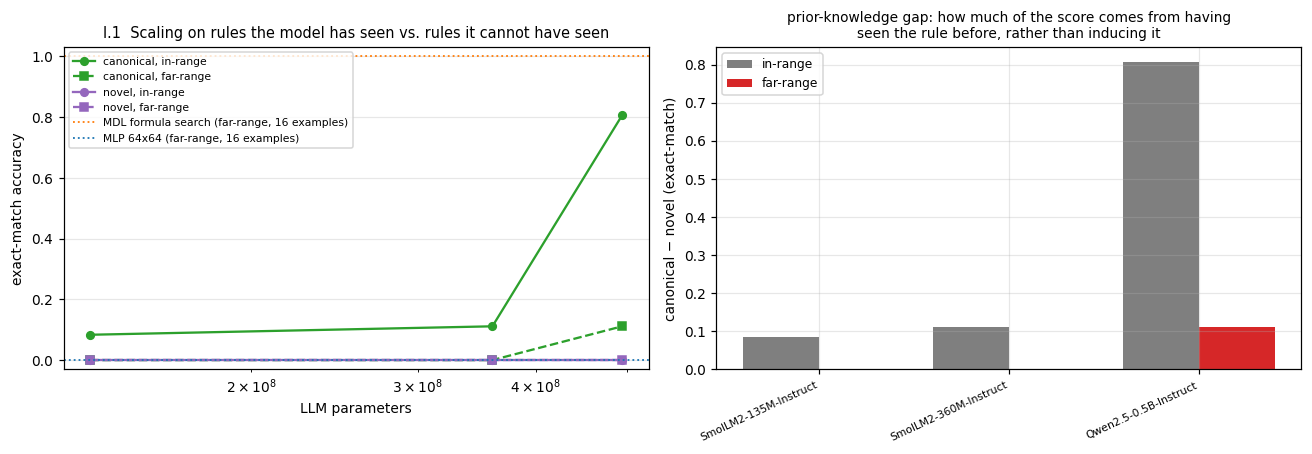


one sampled continuation per model (last prompt line + what was generated):
model
Qwen2.5-0.5B-Instruct    a=21, b=20 =>  28
SmolLM2-135M-Instruct    a=21, b=20 =>  40
SmolLM2-360M-Instruct    a=21, b=20 =>  35


In [18]:
# ===== I.1  open-weight LLMs: memorisable vs. freshly-generated rules ========
import re, gc, subprocess, sys

try:
    from transformers import AutoTokenizer, AutoModelForCausalLM
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "transformers", "accelerate"])
    from transformers import AutoTokenizer, AutoModelForCausalLM

# (hugging-face id, parameters in billions).  Add larger open models if you have VRAM.
LLM_MODELS = [("HuggingFaceTB/SmolLM2-135M-Instruct", 0.135),
              ("HuggingFaceTB/SmolLM2-360M-Instruct", 0.360),
              ("Qwen/Qwen2.5-0.5B-Instruct",          0.494),
              ("Qwen/Qwen2.5-1.5B-Instruct",          1.540),
              ("Qwen/Qwen2.5-3B-Instruct",            3.090)]

HAS_GPU = torch.cuda.is_available()
if not HAS_GPU:
    LLM_MODELS = LLM_MODELS[:3]
    print("no GPU detected -> running only the three smallest models (slower, on CPU)")
N_SHOT, N_QUERY = 16, 12
DEV = "cuda" if HAS_GPU else "cpu"


# ------------------------------------------------------------------ rules ---
def rule_suite(seed=0):
    """Three matched pairs: a canonical rule and a freshly-parameterised twin of the
    same arithmetic form, over identical input ranges."""
    g = np.random.default_rng(seed)
    c = lambda lo, hi: int(g.integers(lo, hi))
    c1, c2, c3 = c(2, 10), c(2, 10), c(10, 99)
    c4, c5 = c(2, 10), c(10, 99)
    c6, c7 = c(2, 10), c(10, 99)
    R = {}
    R["a+b"]            = dict(pair=1, kind="canonical", vars=("a", "b"),
                               f=lambda X: X[:, 0] + X[:, 1], expr="a + b")
    R[f"{c1}a+{c2}b+{c3}"] = dict(pair=1, kind="novel", vars=("a", "b"),
                               f=lambda X: c1 * X[:, 0] + c2 * X[:, 1] + c3,
                               expr=f"{c1}*a + {c2}*b + {c3}")
    R["a*b"]            = dict(pair=2, kind="canonical", vars=("a", "b"),
                               f=lambda X: X[:, 0] * X[:, 1], expr="a * b")
    R[f"{c4}ab+{c5}"]   = dict(pair=2, kind="novel", vars=("a", "b"),
                               f=lambda X: c4 * X[:, 0] * X[:, 1] + c5,
                               expr=f"{c4}*a*b + {c5}")
    R["x^2"]            = dict(pair=3, kind="canonical", vars=("x",),
                               f=lambda X: X[:, 0] ** 2, expr="x^2")
    R[f"{c6}x^2+{c7}"]  = dict(pair=3, kind="novel", vars=("x",),
                               f=lambda X: c6 * X[:, 0] ** 2 + c7,
                               expr=f"{c6}*x^2 + {c7}")
    RANGES = {1: ((0, 50), (500, 2000)), 2: ((1, 16), (40, 100)), 3: ((1, 41), (120, 401))}

    def unique_rows(lo, hi, d, n, exclude=()):
        """Distinct inputs, and in-range queries never repeat a shot -- otherwise the
        in-range score would partly measure copying from the prompt."""
        seen = {tuple(map(int, r)) for r in exclude}
        out = []
        while len(out) < n:
            row = tuple(int(v) for v in g.integers(lo, hi, d))
            if row in seen:
                continue
            seen.add(row); out.append(row)
        return np.array(out)

    for name, r in R.items():
        d = len(r["vars"]); (lo, hi), (elo, ehi) = RANGES[r["pair"]]
        r["shots"] = unique_rows(lo, hi, d, N_SHOT)
        r["q_in"] = unique_rows(lo, hi, d, N_QUERY, exclude=r["shots"])
        r["q_ex"] = unique_rows(elo, ehi, d, N_QUERY)
    return R


def render(r, X):
    return [", ".join(f"{v}={int(x)}" for v, x in zip(r["vars"], row)) for row in X]


def build_prompt(r, query_row):
    lines = [f"{s} => {int(y)}" for s, y in zip(render(r, r["shots"]), r["f"](r["shots"]))]
    return "\n".join(lines) + "\n" + render(r, query_row[None, :])[0] + " =>"


NUM = re.compile(r"-?\d[\d,]*")


def parse_number(txt):
    m = NUM.search(txt.strip())
    if not m:
        return np.nan
    try:
        return float(m.group(0).replace(",", ""))
    except ValueError:
        return np.nan


def scores(y, yh):
    y = np.asarray(y, float); yh = np.asarray(yh, float)
    ok = np.isfinite(yh)
    exact = float(np.mean(ok & (np.abs(yh - y) < 0.5)))
    relerr = float(np.median(np.abs(yh[ok] - y[ok]) / (np.abs(y[ok]) + 1e-9))) if ok.any() else np.nan
    return exact, relerr, (np.clip(r2(y[ok], yh[ok]), -1, None) if ok.sum() > 2 else np.nan)


# ------------------------------------------- small-learner reference lines ---
RULES = rule_suite(0)
base_rows = []
for name, r in RULES.items():
    Xs, ys = r["shots"].astype(float), r["f"](r["shots"]).astype(float)
    for lab, m in [("MDL formula search", MDLFormula()),
                   ("MLP 64x64", TorchMLP((64, 64))),
                   ("Linear", SkModel("lin", "compact", LinearRegression, scale=True))]:
        m.fit(Xs, ys, "regression")
        for zone, Xq in [("in-range", r["q_in"]), ("far-range", r["q_ex"])]:
            e, rel, rr = scores(r["f"](Xq), m.predict(Xq.astype(float)))
            base_rows.append(dict(model=lab, params=np.nan, kind=r["kind"], rule=name,
                                  zone=zone, exact=e, relerr=rel, r2=rr,
                                  formula=getattr(m, "formula", None)))
base = pd.DataFrame(base_rows)
print("reference learners, fitted on the same 16 examples "
      "(exact-match over 12 queries):")
print(base.pivot_table(index="model", columns=["kind", "zone"], values="exact").round(2).to_string())
print("\nformulas recovered for the freshly-generated rules:")
for _, row in base[(base.model == "MDL formula search") & (base.kind == "novel") &
                   (base.zone == "far-range")].iterrows():
    print(f"  true: {RULES[row['rule']]['expr']:22s} found: {row['formula']}")


# --------------------------------------------------------- the LLM sweep ----
llm_rows = []
for repo, bn in LLM_MODELS:
    print(f"\nloading {repo} ...", end=" ", flush=True)
    try:
        tok = AutoTokenizer.from_pretrained(repo)
        model = AutoModelForCausalLM.from_pretrained(
            repo, torch_dtype=torch.float16 if HAS_GPU else torch.float32).to(DEV).eval()
    except Exception as e:
        print("FAILED:", str(e)[:120]); continue
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    tok.padding_side = "left"
    t0 = time.time()
    for name, r in RULES.items():
        for zone, Xq in [("in-range", r["q_in"]), ("far-range", r["q_ex"])]:
            prompts = [build_prompt(r, Xq[i]) for i in range(len(Xq))]
            enc = tok(prompts, return_tensors="pt", padding=True).to(DEV)
            with torch.no_grad():
                out = model.generate(**enc, max_new_tokens=12, do_sample=False,
                                     pad_token_id=tok.pad_token_id)
            gen = tok.batch_decode(out[:, enc["input_ids"].shape[1]:], skip_special_tokens=True)
            preds = np.array([parse_number(g.split("\n")[0]) for g in gen])
            e, rel, rr = scores(r["f"](Xq), preds)
            llm_rows.append(dict(model=repo.split("/")[-1], params=bn * 1e9, kind=r["kind"],
                                 rule=name, zone=zone, exact=e, relerr=rel, r2=rr,
                                 sample=f"{prompts[0].splitlines()[-1]} {gen[0].splitlines()[0][:12]}"))
    print(f"done in {time.time() - t0:.0f}s")
    del model, tok; gc.collect()
    if HAS_GPU:
        torch.cuda.empty_cache()

llm = pd.DataFrame(llm_rows)
if len(llm):
    llm.to_csv(f"{RESULT_DIR}/llm_scaling.csv", index=False)
    piv = llm.pivot_table(index=["model", "params"], columns=["kind", "zone"],
                          values="exact").sort_values("params")
    print("\nexact-match accuracy (12 queries per cell):")
    print(piv.round(2).to_string())

    # --------------------------------------------------------------- plots --
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    styles = {("canonical", "in-range"): ("tab:green", "-", "o"),
              ("canonical", "far-range"): ("tab:green", "--", "s"),
              ("novel", "in-range"): ("tab:purple", "-", "o"),
              ("novel", "far-range"): ("tab:purple", "--", "s")}
    ax = axes[0]
    for (k, z), (c_, ls, mk) in styles.items():
        s = llm[(llm.kind == k) & (llm.zone == z)].groupby("params")["exact"].mean()
        ax.plot(s.index, s.values, ls, marker=mk, color=c_, ms=5, lw=1.5, label=f"{k}, {z}")
    for lab, c_ in [("MDL formula search", "tab:orange"), ("MLP 64x64", "tab:blue")]:
        v = base[(base.model == lab) & (base.zone == "far-range")]["exact"].mean()
        ax.axhline(v, color=c_, ls=":", lw=1.2, label=f"{lab} (far-range, 16 examples)")
    ax.set_xscale("log"); ax.set_xlabel("LLM parameters"); ax.set_ylabel("exact-match accuracy")
    ax.set_ylim(-.03, 1.03); ax.legend(fontsize=7, loc="upper left")
    ax.set_title("I.1  Scaling on rules the model has seen vs. rules it cannot have seen",
                 fontsize=9.5)

    ax = axes[1]
    gap = (llm.pivot_table(index=["model", "params"], columns=["kind", "zone"], values="exact")
           .sort_values("params"))
    xs = np.arange(len(gap))
    ax.bar(xs - .2, gap[("canonical", "in-range")] - gap[("novel", "in-range")],
           width=.4, color="tab:gray", label="in-range")
    ax.bar(xs + .2, gap[("canonical", "far-range")] - gap[("novel", "far-range")],
           width=.4, color="tab:red", label="far-range")
    ax.set_xticks(xs)
    ax.set_xticklabels([m for m, _ in gap.index], rotation=25, ha="right", fontsize=7)
    ax.axhline(0, color="k", lw=.6); ax.set_ylabel("canonical − novel (exact-match)")
    ax.set_title("prior-knowledge gap: how much of the score comes from having\n"
                 "seen the rule before, rather than inducing it", fontsize=9)
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    print("\none sampled continuation per model (last prompt line + what was generated):")
    print(llm.groupby("model").first()["sample"].to_string())
else:
    print("no LLM results -- check the model downloads above")

---
# Part K — Sample efficiency: is the ranking by extrapolation invariant to how much data you have?

This is the experiment that most directly separates your reading of the history from Hasson et al.'s.
Their position is that the apparent need for extrapolation dissolves with dense enough sampling. Yours is
that Newton's laws came from *limited* observations, and that getting the rule from few samples is what
intelligence names. Re-run a reduced zoo with $n_\text{train}\in\{10,30,100,300,1000\}$, test splits fixed.

### What the full run showed: the gap does not close

**Smallest $n$ reaching extrapolation $R^2>0.9$** (up to n = 1000):

| task | MDL search | Linear | Poly-2 ridge | MLP 64×64 | Random forest | k-NN |
|---|---:|---:|---:|---:|---:|---:|
| `poly` | **30** | never | 10 | never | never | never |
| `sine` | **10** | never | never | never | never | never |
| `add` | **10** | 10 | 10 | 10 | never | never |
| `mult` | **10** | never | 10 | never | never | never |

**Slope of extrapolation score in $\log n$**, averaged over tasks: MDL +0.099, MLP +0.063, Poly-2 +0.007,
random forest −0.000, Linear −0.060, k-NN −0.081. Every one is within ±0.1 of zero.

Two conclusions, and they point in opposite directions for the two papers:

* **For your argument.** The dictionary searcher reaches ceiling at **10 examples** on three of four
  tasks — genuine few-shot rule acquisition, in the ARC-like regime, with a readable formula as the
  output. Meanwhile the forests and k-NN never arrive at any $n$ we tested: a hundredfold increase in data
  buys them *nothing* out of distribution. Skill-acquisition efficiency, in Chollet's sense, differs by at
  least two orders of magnitude between models whose in-distribution scores are similar.
* **For Hasson et al.'s.** The flatness cuts both ways. More samples *from the same region* cannot help,
  because they cannot discriminate between hypotheses that agree on that region (Part H's mechanism).
  What their argument actually requires is not more data but **broader** data — which is exactly what the
  "wider support" control in Part G delivers, and what it did successfully. The two papers are not
  disagreeing about a fact; they are disagreeing about whether broad sampling is available in the cases
  that matter.

  sample-efficiency: poly done
  sample-efficiency: sine done
  sample-efficiency: add done
  sample-efficiency: mult done


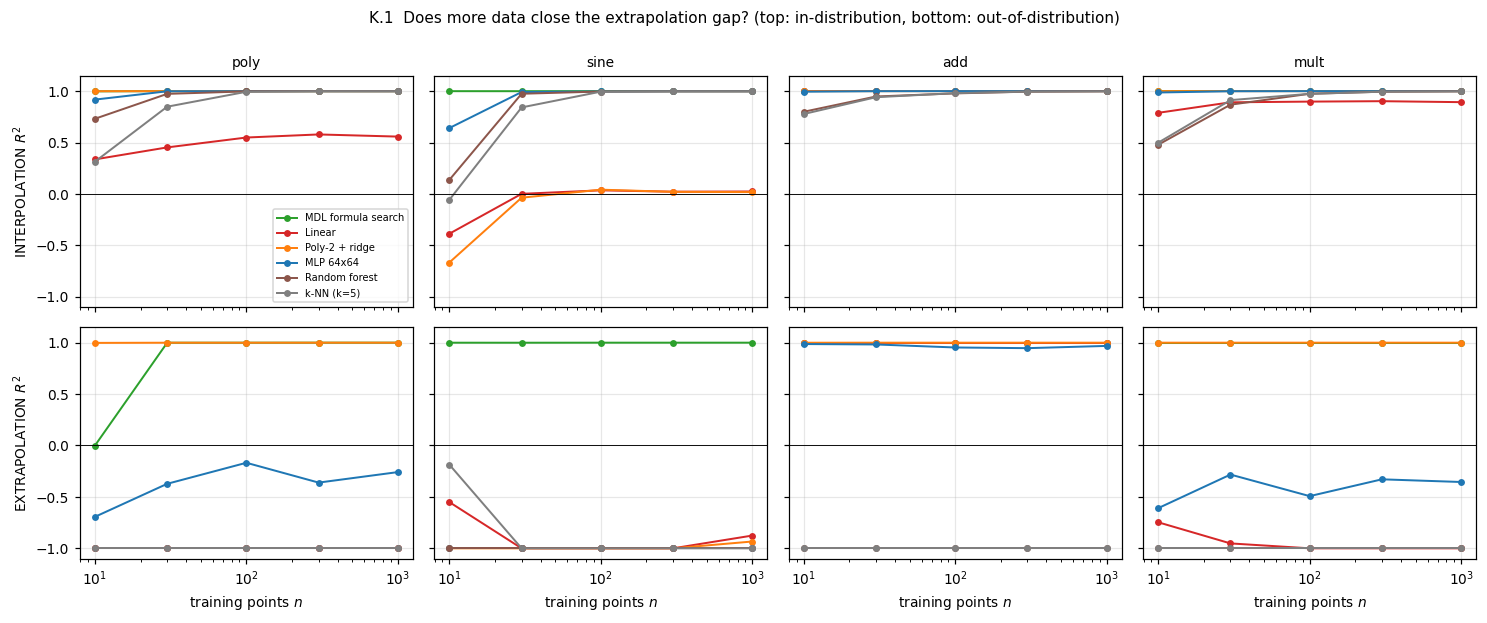

smallest n reaching extrapolation R^2 > 0.9  (None = never, up to n = 1000 )
task MDL formula search Linear Poly-2 + ridge MLP 64x64 Random forest k-NN (k=5)
poly                 30  never             10     never         never      never
sine                 10  never          never     never         never      never
 add                 10     10             10        10         never      never
mult                 10  never             10     never         never      never

slope of extrapolation score in log n (mean over tasks) -- near zero means extra data does not help out of distribution:
MDL formula search    0.099
Linear               -0.060
Poly-2 + ridge        0.007
MLP 64x64             0.063
Random forest        -0.000
k-NN (k=5)           -0.081


In [19]:
# ===================== K.1  sample-efficiency curves =========================
def task_with_n(tname, seed, n):
    """Same task, same test splits, but n training points."""
    global N_TRAIN
    old = N_TRAIN
    try:
        N_TRAIN = n
        return TASK_FNS[tname](seed)
    finally:
        N_TRAIN = old


K_MODELS = {
    "MDL formula search": lambda s: MDLFormula(seed=s),
    "Linear": lambda s: SkModel("lin", "compact", LinearRegression, scale=True),
    "Poly-2 + ridge": lambda s: SkModel("p2", "compact", lambda: Ridge(1e-3), poly=2, scale=True),
    "MLP 64x64": lambda s: TorchMLP((64, 64), seed=s),
    "Random forest": lambda s: SkModel("rf", "piecewise",
                                       lambda: RandomForestRegressor(100, random_state=s, n_jobs=-1)),
    "k-NN (k=5)": lambda s: SkModel("knn", "memory", lambda: KNeighborsRegressor(5), scale=True),
}
K_TASKS = ["poly", "sine", "add", "mult"]
N_LIST = [10, 30, 100, 300] + ([] if QUICK else [1000])
k_seeds = SEEDS[:2]

kr = []
for tname in K_TASKS:
    for seed in k_seeds:
        for n in N_LIST:
            tk = task_with_n(tname, seed, n)
            for label, mk in K_MODELS.items():
                try:
                    m = mk(seed)
                    m.fit(tk.Xtr, tk.ytr, tk.kind)
                    kr.append(dict(task=tname, seed=seed, n=n, model=label,
                                   interp=score(tk.kind, tk.yin, m.predict(tk.Xin)),
                                   extrap=score(tk.kind, tk.yex, m.predict(tk.Xex))))
                except Exception as e:
                    kr.append(dict(task=tname, seed=seed, n=n, model=label,
                                   interp=np.nan, extrap=np.nan))
    print(f"  sample-efficiency: {tname} done")
kdf = pd.DataFrame(kr)
kdf[["interp", "extrap"]] = kdf[["interp", "extrap"]].clip(lower=-1)
kdf.to_csv(f"{RESULT_DIR}/sample_efficiency.csv", index=False)

colors = dict(zip(K_MODELS, ["tab:green", "tab:red", "tab:orange",
                             "tab:blue", "tab:brown", "tab:gray"]))
fig, axes = plt.subplots(2, len(K_TASKS), figsize=(3.4 * len(K_TASKS), 5.6), sharex=True, sharey=True)
for j, tname in enumerate(K_TASKS):
    for i, key in enumerate(["interp", "extrap"]):
        ax = axes[i, j]
        for label in K_MODELS:
            s = (kdf[(kdf.task == tname) & (kdf.model == label)]
                 .groupby("n")[key].mean())
            ax.plot(s.index, s.values, "o-", ms=3.5, lw=1.3, color=colors[label], label=label)
        ax.axhline(0, color="k", lw=.6); ax.set_xscale("log"); ax.set_ylim(-1.1, 1.15)
        if i == 0:
            ax.set_title(tname, fontsize=9)
        if i == 1:
            ax.set_xlabel("training points $n$")
axes[0, 0].set_ylabel("INTERPOLATION $R^2$"); axes[1, 0].set_ylabel("EXTRAPOLATION $R^2$")
axes[0, 0].legend(fontsize=6.5, loc="lower right")
fig.suptitle("K.1  Does more data close the extrapolation gap? "
             "(top: in-distribution, bottom: out-of-distribution)", y=1.0, fontsize=10)
plt.tight_layout(); plt.show()

# smallest n at which each model reaches extrapolation R^2 > 0.9
rows = []
for tname in K_TASKS:
    r = {"task": tname}
    for label in K_MODELS:
        s = kdf[(kdf.task == tname) & (kdf.model == label)].groupby("n")["extrap"].mean()
        good = s[s > 0.9]
        r[label] = str(int(good.index.min())) if len(good) else "never"
    rows.append(r)
print("smallest n reaching extrapolation R^2 > 0.9  (None = never, up to n =", N_LIST[-1], ")")
print(pd.DataFrame(rows).to_string(index=False))

print("\nslope of extrapolation score in log n (mean over tasks) "
      "-- near zero means extra data does not help out of distribution:")
sl = {}
for label in K_MODELS:
    vals = []
    for tname in K_TASKS:
        s = kdf[(kdf.task == tname) & (kdf.model == label)].groupby("n")["extrap"].mean()
        vals.append(np.polyfit(np.log10(s.index.values), s.values, 1)[0])
    sl[label] = np.mean(vals)
print(pd.Series(sl).round(3).to_string())

---
# Part L — Extrapolation as a continuous axis, not a binary label

"Interpolation vs. extrapolation" is a dichotomy imposed by the experimenter's split. Chollet's definition
instead treats *generalization difficulty* as a quantity. Making it continuous turns each model's
behaviour into a **curve**, which is far more informative than a single out-of-distribution number.

We use a representation-free measure: $D$ = median nearest-training-point distance of the test set,
divided by the training set's own nearest-neighbour spacing, all coordinates standardized by training
statistics. $D\approx1$ means test points sit as close to the training set as training points sit to each
other — Hasson's interpolation zone. $D\gg1$ means the test set is off the fitted manifold.

> **Note on the code.** The denominator is now taken over *distinct* training points, and the fraction of
> test items that are exact duplicates of training items is reported separately. Without that fix, the
> discrete tasks (whose token sequences repeat) divide by zero and report $D\sim10^{12}$, which is what the
> first run printed. Re-run cell L.1 for the corrected values quoted below.

### What the full run showed

**Task difficulty.** `poly` 801, `sine` 784, `ap_next` 738, `add` 127, `mult` 90, `parity` 2.2,
`grammar_emb` 1.8, `grammar_1hot` 1.2, `grammar_rel` **0.59**. Three things follow:

* The regression splits are genuinely far (two to three orders of magnitude beyond the training spacing),
  which is why only the symbolic learners survive them.
* `grammar_1hot` sits at $D\approx1.2$ — barely further than the training points are from each other —
  yet **no model beats chance on it**. A metric measure cannot see categorical novelty: one-hot vectors
  are all equidistant. Any difficulty measure is itself a prior about what counts as "far", which is the
  same lesson as Part H.
* `grammar_rel` scores $D<1$: under the relational recoding, a never-seen vocabulary lands **closer** to
  the training set than training points are to each other. That is the sharpest quantitative statement in
  the notebook of what a good representation does — it converts an extrapolation problem into an
  interpolation one. It is also why 55–75% of the *interpolation* items on those tasks are exact repeats
  of training items (`dup_interp` in the table): "interpolation zone" in its strongest form.

**Model reach.** $D^{*}$ = furthest difficulty at which a model still scores above 0.5:

| model | `poly` | `sine` | `add` |
|---|---:|---:|---:|
| MDL formula search | **1956** | **1916** | **162** |
| Poly-2 + ridge | 1956 | 0 | 162 |
| MLP 64×64 | 176 | 1.2 | 17.8 |
| Linear | 0 | 0 | 162 |
| Random forest | 1.1 | 1.2 | 1.0 |
| k-NN (k=5) | 1.1 | 1.2 | 1.0 |

Three orders of magnitude separate the symbolic searcher from the forest — between models whose
*interpolation* scores differ by less than 0.15. Note also that the MLP's $D^{*}$ of 176 on `poly` is not
nothing: it is the quantitative version of the Part F finding that a ReLU net's linear extension carries
it partway, and it makes "extreme generalization" a measurable distance rather than a binary.

generalisation difficulty D of each split (1 = as close as training points are to each other):
        task  D_interp  D_extrap  dup_interp  dup_extrap  mean_extrap_score
        poly      0.88    800.66        0.00         0.0             -0.293
        sine      0.88    784.19        0.00         0.0             -0.615
         add      1.08    127.11        0.00         0.0              0.040
        mult      1.01     89.95        0.00         0.0             -0.274
     ap_next      1.08    738.18        0.00         0.0              0.056
      parity      1.00      2.24        0.00         0.0              0.093
grammar_1hot      0.00      1.19        0.55         0.0              0.014
 grammar_emb      0.00      1.84        0.55         0.0              0.756
 grammar_rel      0.00      0.59        0.75         0.0              1.000

Three things to read off this table:
 * the discrete tasks have a large `dup_interp`: half or more of the interpolation
   items are exact repea

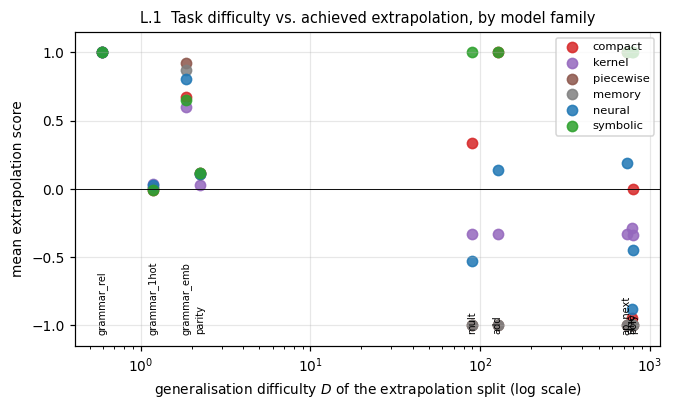

  difficulty sweep: poly done
  difficulty sweep: sine done
  difficulty sweep: add done


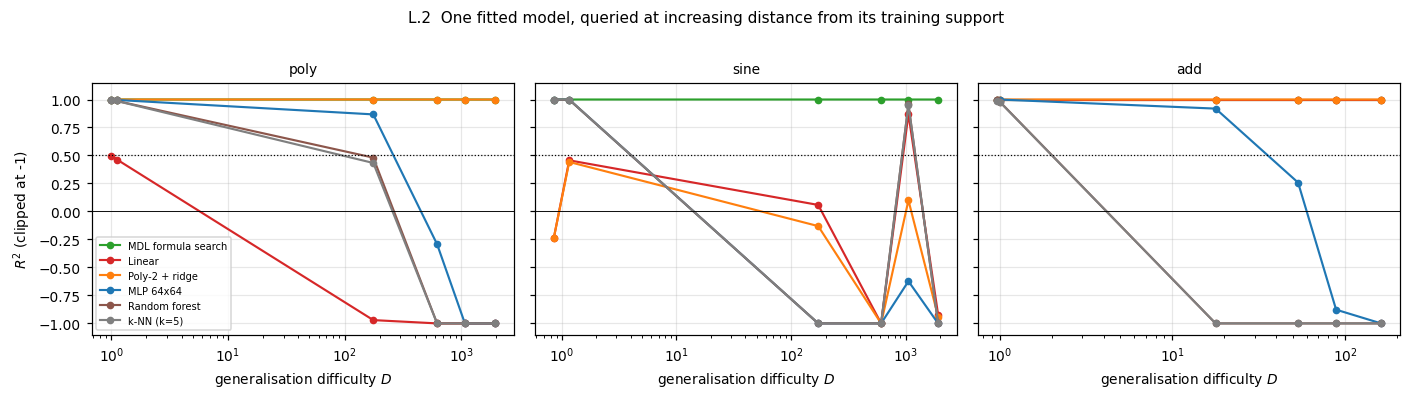

D* = furthest generalisation difficulty at which the model still scores > 0.5
             model   poly   sine   add
MDL formula search 1955.7 1916.2 162.1
            Linear    0.0    0.0 162.1
    Poly-2 + ridge 1955.7    0.0 162.1
         MLP 64x64  176.4    1.2  17.8
     Random forest    1.1    1.2   1.0
        k-NN (k=5)    1.1    1.2   1.0


In [20]:
# ============ L.1  how far away is each benchmark's extrapolation set? =======
from scipy.spatial import cKDTree


def gen_difficulty(Xtr, Xte, return_dup=False):
    """Median nearest-train distance of the test set, in units of the training set's
    own nearest-neighbour spacing (coordinates standardised by train statistics).

    Discrete tasks contain repeated rows (the same 3-token sequence recurs), so the
    raw median training nearest-neighbour distance can be exactly 0 and the ratio
    explodes. We therefore take the denominator over *distinct* training points and
    report separately what fraction of the test set is an exact copy of a training
    point -- which is itself the most direct measure of 'is this really new?'."""
    mu, sd = Xtr.mean(0), Xtr.std(0)
    sd = np.where(sd < 1e-8, 1.0, sd)      # constant training dims (e.g. unused one-hot units)
    A, B = (Xtr - mu) / sd, (Xte - mu) / sd
    tree = cKDTree(A)
    d_te, _ = tree.query(B, k=1)
    d_tr, _ = tree.query(A, k=2)
    pos = d_tr[:, 1][d_tr[:, 1] > 1e-9]
    denom = float(np.median(pos)) if len(pos) else 1.0
    D = float(np.median(d_te) / denom)
    return (D, float(np.mean(d_te < 1e-9))) if return_dup else D


diff_rows = []
for tname in TASKS:
    tk = TASK_FNS[tname](0)
    Di, dup_i = gen_difficulty(tk.Xtr, tk.Xin, return_dup=True)
    De, dup_e = gen_difficulty(tk.Xtr, tk.Xex, return_dup=True)
    diff_rows.append(dict(task=tname, D_interp=round(Di, 2), D_extrap=round(De, 2),
                          dup_interp=round(dup_i, 2), dup_extrap=round(dup_e, 2)))
ddf = pd.DataFrame(diff_rows)
task_mean = ok.groupby("task")["extrap_c"].mean()
ddf["mean_extrap_score"] = ddf["task"].map(task_mean).round(3)
print("generalisation difficulty D of each split (1 = as close as training points are "
      "to each other):")
print(ddf.to_string(index=False))

print("\nThree things to read off this table:\n"
      " * the discrete tasks have a large `dup_interp`: half or more of the interpolation\n"
      "   items are exact repeats of training items, which is what 'interpolation zone'\n"
      "   means in its strongest form.\n"
      " * grammar_1hot and grammar_emb sit at D ~ 1-2, i.e. barely further away than the\n"
      "   training points are from each other, yet no model solves grammar_1hot. A metric\n"
      "   measure of novelty cannot see categorical novelty: every one-hot vector is\n"
      "   equidistant from every other. Any difficulty measure is itself a prior about\n"
      "   what counts as 'far' -- the same point Part H makes about identifiability.\n"
      " * grammar_rel scores D < 1: under the relational recoding the never-seen\n"
      "   vocabulary lands CLOSER to the training set than training points are to each\n"
      "   other. That is what a good representation does -- it converts an extrapolation\n"
      "   problem into an interpolation one.")

fig, ax = plt.subplots(figsize=(6.2, 3.8))
for fam, c in fam_color.items():
    s = ok[ok.family == fam].groupby("task")["extrap_c"].mean()
    xs = ddf.set_index("task").loc[s.index, "D_extrap"]
    ax.scatter(xs, s.values, color=c, s=45, label=fam, alpha=.85)
for _, r in ddf.iterrows():
    ax.annotate(r["task"], (r["D_extrap"], -1.05), fontsize=6.5, rotation=90, ha="center")
ax.set_xscale("log"); ax.axhline(0, color="k", lw=.6); ax.set_ylim(-1.15, 1.15)
ax.set_xlabel("generalisation difficulty $D$ of the extrapolation split (log scale)")
ax.set_ylabel("mean extrapolation score")
ax.set_title("L.1  Task difficulty vs. achieved extrapolation, by model family", fontsize=9.5)
ax.legend(fontsize=7.5, loc="upper right"); plt.tight_layout(); plt.show()


# ============ L.2  sliding the test window away from the training support ====
RULES = {"poly": lambda X: X[:, 0] ** 2 - 3 * X[:, 0] + 2,
         "sine": lambda X: np.sin(X[:, 0]),
         "add":  lambda X: X[:, 0] + X[:, 1]}
SHIFTS = [0.2, 0.6, 1.0, 1.5, 2.0, 3.0]          # 0.2, 0.6 are inside the training range


def shifted_test(tname, shift, g, n=300):
    if tname in ("poly", "sine"):                 # training support |x| < 5
        x = g.choice([-1., 1.], n) * g.uniform(5 * shift, 5 * shift + 2, n)
        X = x[:, None]
    else:                                         # 'add': training support [0,50]^2
        X = g.uniform(50 * shift, 50 * shift + 20, (n, 2))
    return X, RULES[tname](X)


lr_rows = []
for tname in RULES:
    for seed in k_seeds:
        tk = TASK_FNS[tname](seed)
        g = np.random.default_rng(1234 + seed)
        tests = {s: shifted_test(tname, s, g) for s in SHIFTS}
        for label, mk in K_MODELS.items():
            m = mk(seed).fit(tk.Xtr, tk.ytr, "regression")     # fitted ONCE
            for s, (Xs, ys) in tests.items():
                lr_rows.append(dict(task=tname, seed=seed, model=label, shift=s,
                                    D=gen_difficulty(tk.Xtr, Xs),
                                    score=np.clip(r2(ys, m.predict(Xs)), -1, None)))
    print(f"  difficulty sweep: {tname} done")
ldf = pd.DataFrame(lr_rows)
ldf.to_csv(f"{RESULT_DIR}/difficulty_sweep.csv", index=False)

fig, axes = plt.subplots(1, len(RULES), figsize=(4.3 * len(RULES), 3.5), sharey=True)
for ax, tname in zip(np.atleast_1d(axes), RULES):
    for label in K_MODELS:
        s = ldf[(ldf.task == tname) & (ldf.model == label)].groupby("shift").agg(
            D=("D", "mean"), sc=("score", "mean"))
        ax.plot(s["D"], s["sc"], "o-", ms=4, lw=1.4, color=colors[label], label=label)
    ax.axhline(0.5, color="k", ls=":", lw=.8); ax.axhline(0, color="k", lw=.6)
    ax.set_xscale("log"); ax.set_xlabel("generalisation difficulty $D$")
    ax.set_title(tname, fontsize=9); ax.set_ylim(-1.1, 1.15)
np.atleast_1d(axes)[0].set_ylabel("$R^2$ (clipped at -1)")
np.atleast_1d(axes)[0].legend(fontsize=6.5, loc="lower left")
fig.suptitle("L.2  One fitted model, queried at increasing distance from its training support",
             y=1.02, fontsize=10)
plt.tight_layout(); plt.show()


def d_star(sub):
    """Furthest D reached before the score first drops below 0.5 (read monotonically,
    so an accidental rebound at a far distance does not count)."""
    s = sub.groupby("shift").agg(D=("D", "mean"), sc=("score", "mean")).sort_values("D")
    best = 0.0
    for D_, sc_ in zip(s.D, s.sc):
        if sc_ <= 0.5:
            break
        best = float(D_)
    return best


print("D* = furthest generalisation difficulty at which the model still scores > 0.5")
print(pd.DataFrame([{**{"model": lab},
                     **{t: round(d_star(ldf[(ldf.task == t) & (ldf.model == lab)]), 1)
                        for t in RULES}}
                    for lab in K_MODELS]).to_string(index=False))

---
# Part J — What the results say, and where to take them next

## J.1 The findings, stated as claims you could defend

**1. The essay's thesis is directionally right and causally mislabelled.** Compact, interpretable models
do dominate the extrapolation leaderboard (symbolic regression 1.000, MDL search 0.751, polynomial ridge
0.640 — against −0.32 for forests and −0.34 for k-NN). But parameter count is not what produces this.
The single worst extrapolator in the entire zoo is an **11-parameter** degree-10 polynomial (−1.000), and
within a fixed architecture *more* capacity helps (ρ = +0.82 and +0.91 in Part F). The variable that
predicts extrapolation is whether the hypothesis space contains the rule. Kepler's ellipse is short
because it is true, not true because it is short.

**2. Interpolation and extrapolation are near-orthogonal abilities, not a trade-off.** ρ = −0.086
(p = 0.73) between the two leaderboards. This is a stronger and more useful claim than the reversal H1
predicted, because it means a model can be improved on one axis without paying on the other — which is
what Part G then demonstrates.

**3. Priors buy extrapolation without costing capacity — the Conjecture survives.** Symmetry augmentation
moved the same 64×64 network from −0.22 to +1.00 (`mult`) and from −1.00 to +0.44 (`sine`). But note which
priors failed: weight decay (frugality as regularization) made things worse everywhere, and a correct-but-
awkward prior (sine activation) failed even on the task it was right about. "Add priors" is not a recipe;
the prior has to be the right *kind* and has to be learnable.

**4. Representation is the most powerful single lever.** The grammar ladder — chance under one-hot
tokens, 0.95–1.00 under distributed embeddings, 1.00 for every model under relational recoding — changes
nothing about capacity and everything about the result. In $D$ terms the relational recoding moves a
never-seen vocabulary from "outside" to **closer than the training data is to itself**.

**5. Data quantity is the wrong axis; data *breadth* is the right one.** Extrapolation score is flat in
$n$ over two orders of magnitude for every model (slopes within ±0.1), yet widening the training support
fixed all three tasks in Part G. The disagreement between the essay and *Direct Fit to Nature* is
therefore not about a fact but about availability: dense sampling of the far region works when you can
have it, and the interesting cases are the ones where you cannot.

**6. For small language models, scale buys recall rather than rule induction.** Canonical in-range
exact-match rose 0.08 → 0.81 across three models spanning 0.135B → 0.5B parameters; the freshly-generated
twins stayed at exactly 0.00 in every cell, at both distances. Stated carefully: over the range tested,
additional scale improved performance only on the rule the model had seen before. This is the same shape
as claims 2 and 5 — capacity and data buy in-distribution performance without buying the rule — and it is
consistent with larger-scale reports that LLM accuracy tracks task frequency in pre-training
(McCoy et al., 2023; Mirzadeh et al., 2024). It is *not* a claim about frontier models, which this
notebook cannot run.

**7. Some failures are the split's fault, not the model's.** The `parity` split leaves a 638-dimensional
space of hypotheses that fit the training region exactly and disagree outside it. No learner can be
blamed for that, and no benchmark should report it as a model property.

## J.2 Honest caveats

* **Effective parameter count is a convention** (storage-based here). Trees, kernels and nets are not
  commensurable by parameter count in any deep sense. Since claim 1 turns on this axis, report the
  convention explicitly and check the pattern survives alternatives (VC-style capacity; bits to reach a
  fixed training error).
* **The symbolic learners' success is a prior, not a miracle.** `MDLFormula` recovers $\sin x$ because
  $\sin$ is in its dictionary; `gplearn` because `sin` is in its function set. Remove them and both fail
  like the MLP. This is the point, but it must be stated or the result reads as circular. The clean
  follow-up is the held-out-primitive experiment in J.3.
* **Nine splits, three seeds, one noise level.** `extrap_sd` is large for several models (0.6–0.8),
  because scores are bimodal across tasks — a model either has the rule or does not. Means hide that;
  quote the per-task matrix as well.
* **`gplearn`'s expressions are not always parsimonious** — its `poly` solution is a 40-node tree that
  happens to equal $x^2-3x+2$. Perfect extrapolation and true interpretability came apart there, which is
  a small but real counterexample to the claim that the two always travel together.

## J.3 Natural extensions

*(Extensions 1 and 2 are implemented as Parts K and L.)*

1. ✅ **Sample-efficiency curves** (Part K). Extend upward in $n$ and add the classification tasks.
2. ✅ **Generalization difficulty as a continuous axis** (Part L). Strengthen with a non-metric measure
   (convex-hull membership, density ratio), since nearest-neighbour distance is blind to categorical
   novelty, as `grammar_1hot` shows.
3. **A held-out-primitive experiment.** Re-run `MDLFormula` and `gplearn` with the correct primitive
   deleted from the dictionary/function set, to measure how gracefully frugal methods degrade when their
   priors are wrong. This is the honest counterweight to Parts A and E and, I think, the most valuable
   single experiment left undone.
4. **Stronger symbolic baselines**: PySR (multi-objective, Julia backend), DreamCoder-style library
   learning, or an enumerative program synthesizer over a DSL — the modern descendants of the
   "principles-driven" approach the essay defends.
5. **An ARC-lite grid task.** Keep ARC's format but restrict to one compositional family
   (translate–recolour–reflect), so ordinary learners score above zero and the axis stays measurable.
6. **Noise sweep.** Only `poly` and `sine` carry observation noise. BIC selection is noise-robust, so the
   frugal models' advantage should *grow* with noise — a cheap and falsifiable prediction.

## J.4 Reproducibility

Raw results are written to `results/`: `benchmark_raw.csv`, `capacity_sweep.csv`,
`priors_ablation.csv`, `sample_efficiency.csv`, `difficulty_sweep.csv`, `llm_scaling.csv`. The full run
quoted throughout used `QUICK = False`, `SEEDS = [0,1,2]`, gplearn enabled: 453 fits in 36 minutes on a
CPU runtime. The only stochastic elements are the data samples, network initialisations, and the gplearn
search.

The notebook and all result CSVs are available at the companion repository (replace with your URL):
`https://github.com/<your-username>/ptolemy-to-newton`.